In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import plotly.graph_objects as go


In [2]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr

#Persentase Identik
#-------------------------------------------------------------------------
def persentase_identik(matrik_utama, matrik_pembanding):
    """
    Menghitung persentase kesamaan elemen (nilai identik) antara dua matriks.

    Args:
        matrik_utama (list[list] | np.ndarray): Matriks pertama (referensi)
        matrik_pembanding (list[list] | np.ndarray): Matriks kedua (dibandingkan)

    Returns:
        float: Persentase kesamaan dalam rentang 0–100
    """
    # Konversi ke numpy array
    a = np.array(matrik_utama)
    b = np.array(matrik_pembanding)

    # Pastikan ukuran sama
    if a.shape != b.shape:
        raise ValueError(f"Ukuran matriks berbeda: {a.shape} vs {b.shape}")

    # Hitung jumlah elemen identik
    sama = np.sum(a == b)
    total = a.size

    # Persentase identik
    persentase = (sama / total) * 100
    return round(persentase, 2)



#Mean Squared Error (MSE) atau Root Mean Squared Error (RMSE)
#-------------------------------------------------------------------------
def mse_rmse(matrik_utama, matrik_pembanding):
    """
    Menghitung Mean Squared Error (MSE) dan Root Mean Squared Error (RMSE)
    antara dua matriks dengan ukuran sama.

    Args:
        matrik_utama (list[list] | np.ndarray): Matriks referensi
        matrik_pembanding (list[list] | np.ndarray): Matriks pembanding

    Returns:
        dict: {'MSE': float, 'RMSE': float}
    """
    # Konversi ke numpy array
    a = np.array(matrik_utama, dtype=float)
    b = np.array(matrik_pembanding, dtype=float)

    # Pastikan ukuran sama
    if a.shape != b.shape:
        raise ValueError(f"Ukuran matriks berbeda: {a.shape} vs {b.shape}")

    # Hitung selisih
    diff = a - b

    # Mean Squared Error
    mse = np.mean(diff ** 2)

    # Root Mean Squared Error
    rmse = np.sqrt(mse)

    return {'MSE': round(mse, 4), 'RMSE': round(rmse, 4)}

#Cosine Similarity
#-------------------------------------------------------------------------
def cosine_similarity_matrix(matrik_utama, matrik_pembanding, mode='persen'):
    """
    Menghitung Cosine Similarity antara dua matriks.

    Args:
        matrik_utama (list[list] | np.ndarray): Matriks referensi
        matrik_pembanding (list[list] | np.ndarray): Matriks pembanding
        mode (str): 'persen' untuk output 0–100%, 
                    'index' untuk output -1 sampai 1

    Returns:
        float: Nilai cosine similarity sesuai mode
    """
    # Konversi ke numpy array
    a = np.array(matrik_utama, dtype=float)
    b = np.array(matrik_pembanding, dtype=float)

    # Pastikan ukuran sama
    if a.shape != b.shape:
        raise ValueError(f"Ukuran matriks berbeda: {a.shape} vs {b.shape}")

    # Flatten menjadi vektor 1D
    a_flat = a.flatten()
    b_flat = b.flatten()

    # Hitung Cosine Similarity (hasil antara -1 sampai 1)
    sim = cosine_similarity(a_flat.reshape(1, -1), b_flat.reshape(1, -1))[0][0]

    # Pilih mode output
    if mode == 'persen':
        return round(sim * 100, 2)
    elif mode == 'index':
        return round(sim, 4)
    else:
        raise ValueError("Parameter 'mode' harus 'persen' atau 'index'.")
        
#Pearson Correlation
#-------------------------------------------------------------------------
def pearson_similarity_matrix(matrix_a, matrix_b, mode="index"):
    """
    Menghitung kesamaan dua matriks berdasarkan Pearson Correlation.
    
    Args:
        matrix_a (list or np.ndarray): Matriks utama.
        matrix_b (list or np.ndarray): Matriks pembanding.
        mode (str): 'index' untuk nilai -1 s.d. 1, 
                    'persen' untuk output 0–100%.
    
    Returns:
        float: Nilai korelasi atau persentase kesamaan.
    """
    a = np.array(matrix_a).flatten()
    b = np.array(matrix_b).flatten()

    if len(a) != len(b):
        raise ValueError("Kedua matriks harus memiliki jumlah elemen yang sama.")
    
    corr, _ = pearsonr(a, b)
    
    if mode == "persen":
        return round((corr + 1) / 2 * 100, 2)  # ubah -1–1 menjadi 0–100%
    else:
        return round(corr, 4)

    
def show_candlestick(df, title="Candlestick Chart"):
    """
    Menampilkan candlestick chart dari DataFrame.
    
    Parameter:
    ----------
    df : pandas.DataFrame
        Harus memiliki kolom: 'Timestamp', 'Open', 'High', 'Low', 'Close'.
    title : str
        Judul grafik.
    """
    # pastikan Timestamp bertipe datetime
    if not pd.api.types.is_datetime64_any_dtype(df['Timestamp']):
        df = df.copy()
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    
    # buat candlestick chart
    fig = go.Figure(
        data=[
            go.Candlestick(
                x=df['Timestamp'],
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'],
                increasing_line_color='green',
                decreasing_line_color='red',
                name='Candlestick'
            )
        ]
    )

    # layout dan tampilan
    fig.update_layout(
        title=title,
        xaxis_title='Timestamp',
        yaxis_title='Price',
        xaxis_rangeslider_visible=False,
        template='plotly_white',
        height=500,
    )

    fig.show()
    
def gobal_normalisasi(df, numeric_cols = ['Open', 'High', 'Low', 'Close']):
    global_min = df[numeric_cols].min().min()
    global_max = df[numeric_cols].max().max()
    return round((df[numeric_cols] - global_min) / (global_max - global_min), 3)

In [12]:


# === 1️⃣ Load Data ===
file_name = "btc_data_hourly.csv"
df = pd.read_csv('data/' + file_name)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

#Parameter Utama ===
target_time = pd.Timestamp("2024-01-21 11:00:00")
window_size = 6

numeric_cols = ['Open', 'High', 'Low', 'Close']
#Ambil Window Target ===
# Ambil window target
idx_target = df.index[df['Timestamp'] == target_time]
if len(idx_target) == 0:
    raise ValueError("Timestamp tidak ditemukan dalam data.")
idx_target = idx_target[0]

if idx_target < window_size - 1:
    raise ValueError("Data sebelum timestamp target tidak cukup.")
target_window = df.iloc[idx_target - window_size + 1 : idx_target + 1][['Timestamp','Open','High','Low','Close']]

# Simpan Timestamp dulu
timestamps = target_window['Timestamp']

# Normalisasi hanya kolom numerik
target_scaled = gobal_normalisasi(target_window)

# Gabungkan kembali dengan Timestamp
target_norm = target_window.copy()
target_norm[numeric_cols] = target_scaled


target_norm

,Timestamp,Open,High,Low,Close
56226,2024-01-21 06:00:00,0.244,0.345,0.000,0.127
56227,2024-01-21 07:00:00,0.127,0.402,0.087,0.321
56228,2024-01-21 08:00:00,0.321,0.555,0.321,0.379
56229,2024-01-21 09:00:00,0.379,0.698,0.379,0.698
56230,2024-01-21 10:00:00,0.698,1.000,0.555,0.844
56231,2024-01-21 11:00:00,0.844,0.881,0.463,0.592


In [13]:
target_out = df.iloc[idx_target  + 1 ][['Timestamp','Open','High','Low','Close']]
real_out = ""
if(target_out.Close  > target_norm.iloc[-1].Close):
    real_out = 'UP'
elif(target_out.Close  < target_norm.iloc[-1].Close):
    real_out = 'DOWN'
else:
    real_out = 'HOLD'

In [14]:
#show_candlestick(target_norm, title="Candlestick Normalized Window")

In [15]:
from tqdm import tqdm
results = []
trashhold_cosine_similarity = 97
trashhold_persentase_identik = 11
trashhold_mse = 0.018 #0.03#0.018

pbar = tqdm(range(window_size - 1, idx_target), desc="Processing windows", unit="window")

for i in pbar:
    past_window = df.iloc[i - window_size + 1 : i + 1]#[numeric_cols]
    if len(past_window) < window_size:
        continue
        
    past_norm = gobal_normalisasi(past_window)
    
    # Flatten agar tiap candle dianggap berurutan (Open,High,Low,Close,Volume,...)
    a = target_norm[numeric_cols].values.tolist()
    b = past_norm[numeric_cols].values.tolist()
    
    # Persentase Identik
    persentase_identik_val = persentase_identik(a, b)
    
    # MSE RMSE
    mse_rmse_val = mse_rmse(a, b)
    
    #cosine_similarity_matrix
    cosine_similarity_matrix_val = cosine_similarity_matrix(a, b, mode='persen')

    #pearson_similarity_matrix
    pearson_similarity_matrix_val = pearson_similarity_matrix(a, b, mode='persen')
    
    if(cosine_similarity_matrix_val >= trashhold_cosine_similarity and persentase_identik_val >= trashhold_persentase_identik and  mse_rmse_val["MSE"] <= trashhold_mse):
        tmp = {}
        tmp['timestamp'] = past_window['Timestamp'].values.tolist()
        tmp['data'] = b
        tmp['val_persentase_identik'] = persentase_identik_val
        tmp['val_mse'] = mse_rmse_val['MSE']
        tmp['val_rmse'] = mse_rmse_val['RMSE']
        tmp['val_cosine_similarity'] = cosine_similarity_matrix_val
        tmp['val_pearson_similarity'] = pearson_similarity_matrix_val
        # --- Prediksi hasil setelah window ---
        if i + 1 < len(df):
            next_close = df.iloc[i + 1]['Close']
            current_close = df.iloc[i]['Close']
            if (next_close > current_close):
                tmp['result'] = "UP"
            elif(next_close > current_close):
                tmp['result'] = "DOWN"
            else:
                tmp['result'] = "HOLD"
        else:
            tmp['result'] = "HOLD"
        
        results.append(tmp)
    pbar.set_postfix({'matches': len(results)})

pbar.close()
print(f"\nTotal hasil lolos threshold: {len(results)}")
    

Processing windows: 100%|██████████| 56226/56226 [04:57<00:00, 188.87window/s, matches=49]


Total hasil lolos threshold: 49


In [16]:
print(f"total : {len(results)}")
# Konversi ke DataFrame ringkas
records = []
for item in results:
    ts = item['timestamp']
    record = {
        'date_start': pd.to_datetime(ts[0], unit='ns'),
        'date_end': pd.to_datetime(ts[-1], unit='ns'),
        'val_persentase_identik': item['val_persentase_identik'],
        'val_mse': item['val_mse'],
        'val_rmse': item['val_rmse'],
        'val_cosine_similarity': item['val_cosine_similarity'],
        'val_pearson_similarity': item['val_pearson_similarity'],
        'result': item['result'],
        'out_asli': real_out
    }
    records.append(record)

df = pd.DataFrame(records)
df = df.sort_values(by='val_persentase_identik', ascending=False).reset_index(drop=True)
df.head(100)

total : 49


,date_start,date_end,val_persentase_identik,val_mse,val_rmse,val_cosine_similarity,val_pearson_similarity,result,out_asli
0,2017-10-30 21:00:00,2017-10-31 02:00:00,20.83,0.0126,0.1123,97.81,95.97,UP,UP
1,2021-08-11 04:00:00,2021-08-11 09:00:00,20.83,0.0120,0.1096,98.09,95.93,HOLD,UP
2,2020-11-28 12:00:00,2020-11-28 17:00:00,20.83,0.0126,0.1121,98.21,96.88,HOLD,UP
3,2019-10-02 20:00:00,2019-10-03 01:00:00,16.67,0.0156,0.1248,97.37,95.94,UP,UP
4,2024-01-04 11:00:00,2024-01-04 16:00:00,16.67,0.0098,0.0989,98.50,97.32,UP,UP
5,2022-01-31 04:00:00,2022-01-31 09:00:00,16.67,0.0176,0.1326,97.41,94.54,UP,UP
6,2020-11-16 03:00:00,2020-11-16 08:00:00,16.67,0.0151,0.1227,98.46,96.92,UP,UP
7,2024-01-06 14:00:00,2024-01-06 19:00:00,16.67,0.0147,0.1213,97.71,95.07,HOLD,UP
8,2018-10-30 01:00:00,2018-10-30 06:00:00,16.67,0.0141,0.1188,97.54,95.22,HOLD,UP
9,2019-03-02 09:00:00,2019-03-02 14:00:00,12.50,0.0153,0.1238,97.32,94.61,HOLD,UP


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

def show_candlestick_comparison(record, data_ori):
    """
    Menampilkan 2 candlestick (kiri-kanan) dan informasi metrik di bawahnya.

    Args:
        record (dict): Berisi 'data' (data_ref) serta val_mse, val_rmse, dll.
        data_ori (list): List of [Open, High, Low, Close] untuk original.
    """

    # === Konversi ke DataFrame agar bisa ditampilkan dengan mplfinance ===
    data_ref = record['data']
    df_ref = pd.DataFrame(data_ref, columns=['Open', 'High', 'Low', 'Close'])
    df_ori = pd.DataFrame(data_ori, columns=['Open', 'High', 'Low', 'Close'])

    # Tambahkan timestamp dummy biar bisa diplot
    df_ref['Timestamp'] = pd.date_range('2023-01-01', periods=len(df_ref), freq='H')
    df_ref.set_index('Timestamp', inplace=True)

    df_ori['Timestamp'] = pd.date_range('2023-01-01', periods=len(df_ori), freq='H')
    df_ori.set_index('Timestamp', inplace=True)

    # === Buat figure besar (2 plot sejajar) ===
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Candlestick referensi (kiri)
    mpf.plot(df_ref, type='candle', ax=axes[0], style='charles')
    axes[0].set_ylabel("Price (normalized)")

    # Candlestick original (kanan)
    mpf.plot(df_ori, type='candle', ax=axes[1], style='charles')
    axes[1].set_ylabel("Price (normalized)")

    # === Tabel hasil metrik di bawah grafik ===
    cell_text = [[
        f"{record.get('val_persentase_identik', 0):.2f}%",
        f"{record.get('val_mse', 0):.4f}",
        f"{record.get('val_rmse', 0):.4f}",
        f"{record.get('val_cosine_similarity', 0):.2f}",
        f"{record.get('val_pearson_similarity', 0):.2f}",
        f"{record.get('result', '-')}"
    ]]

    col_labels = [
        "val_persentase_identik",
        "val_mse",
        "val_rmse",
        "val_cosine_similarity",
        "val_pearson_similarity",
        "result"
    ]

    table = plt.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='bottom',
        bbox=[0.0, -0.35, 1, 0.2]  # posisi tabel di bawah grafik
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)

    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()


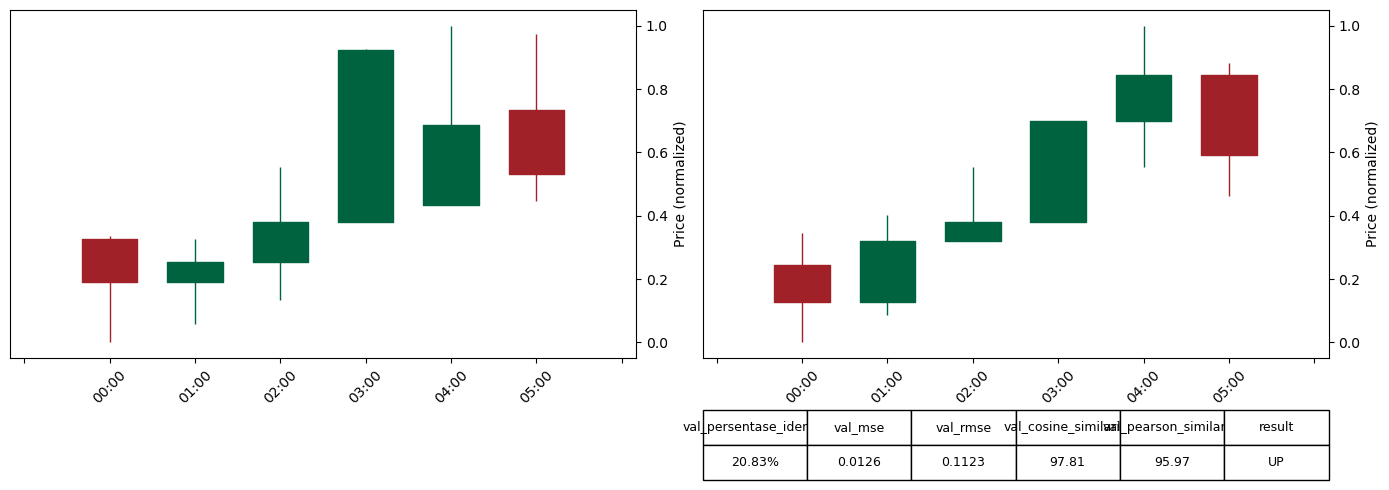

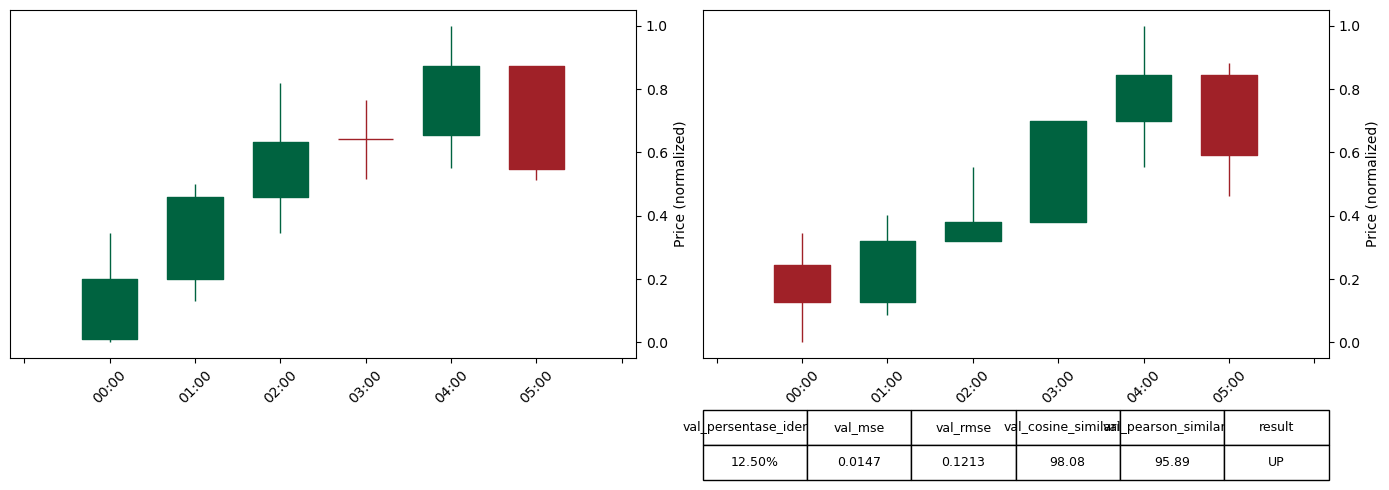

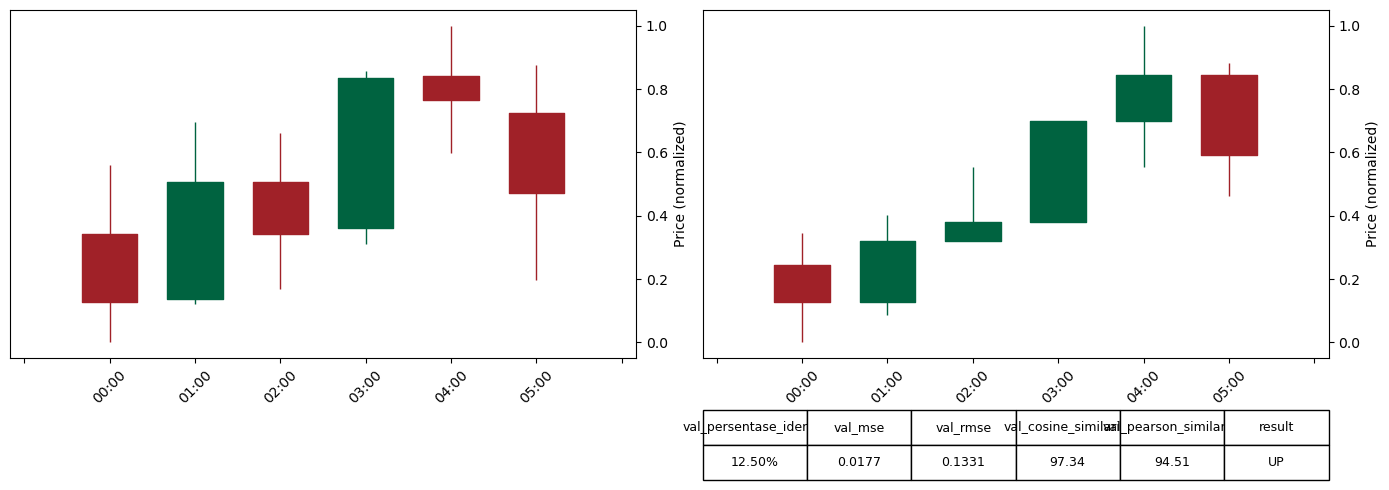

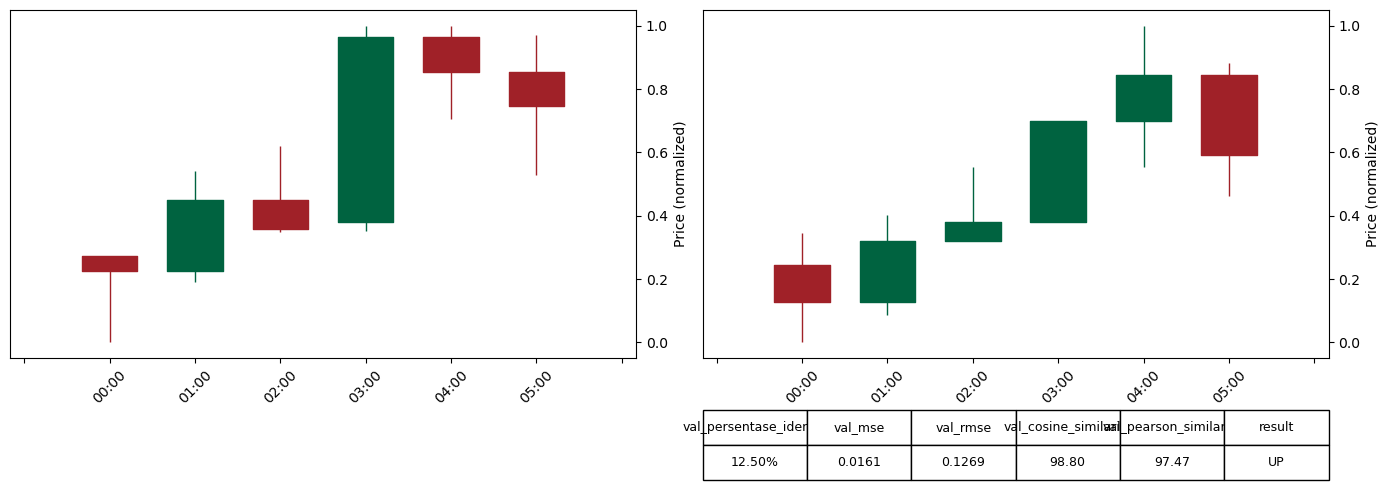

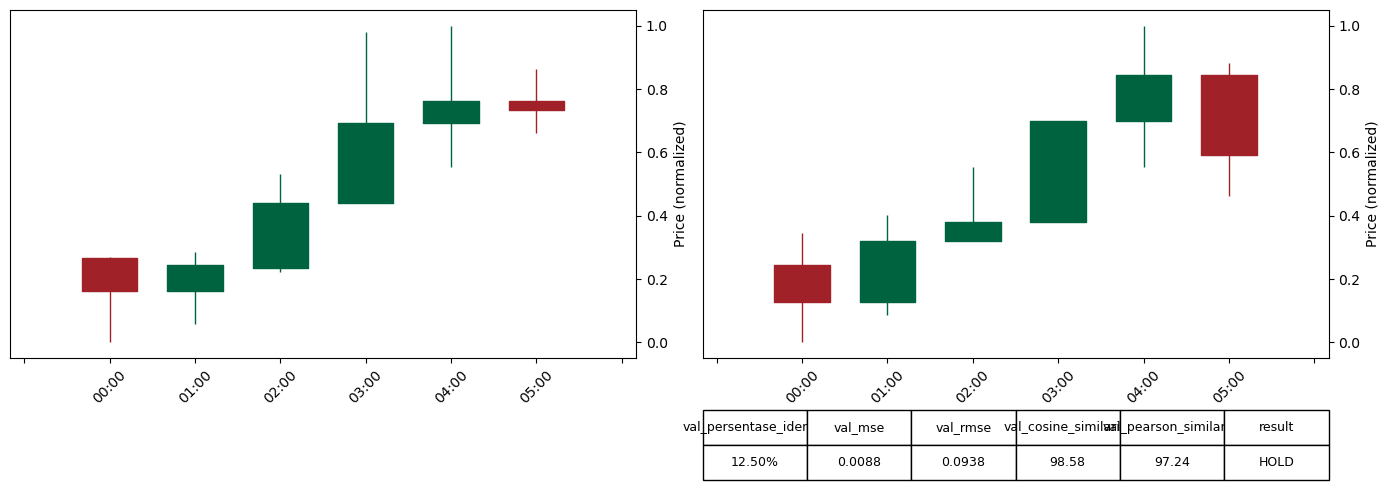

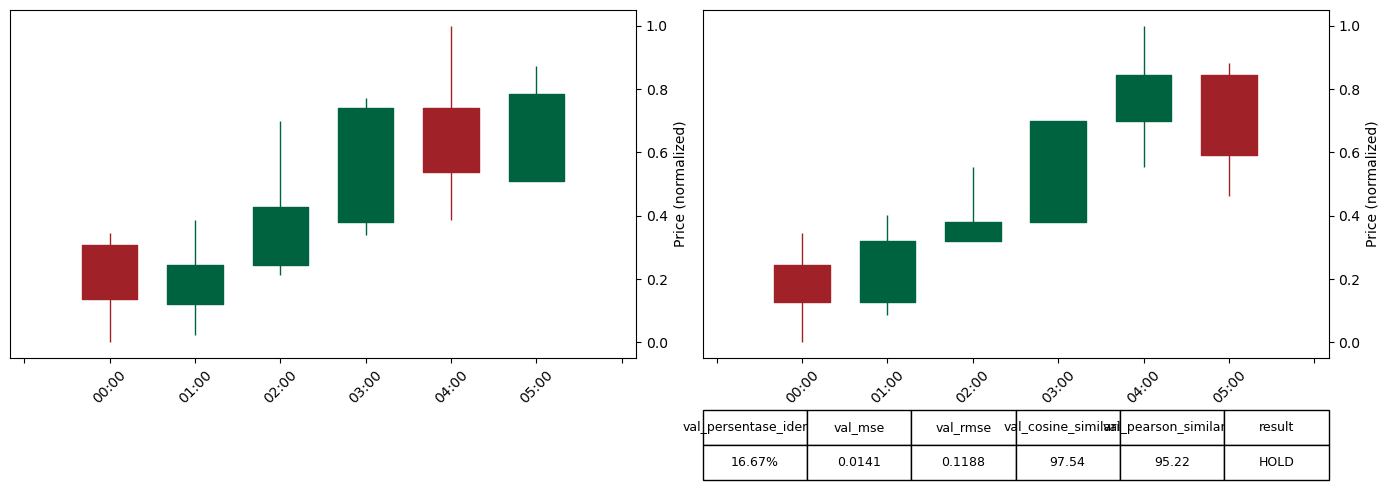

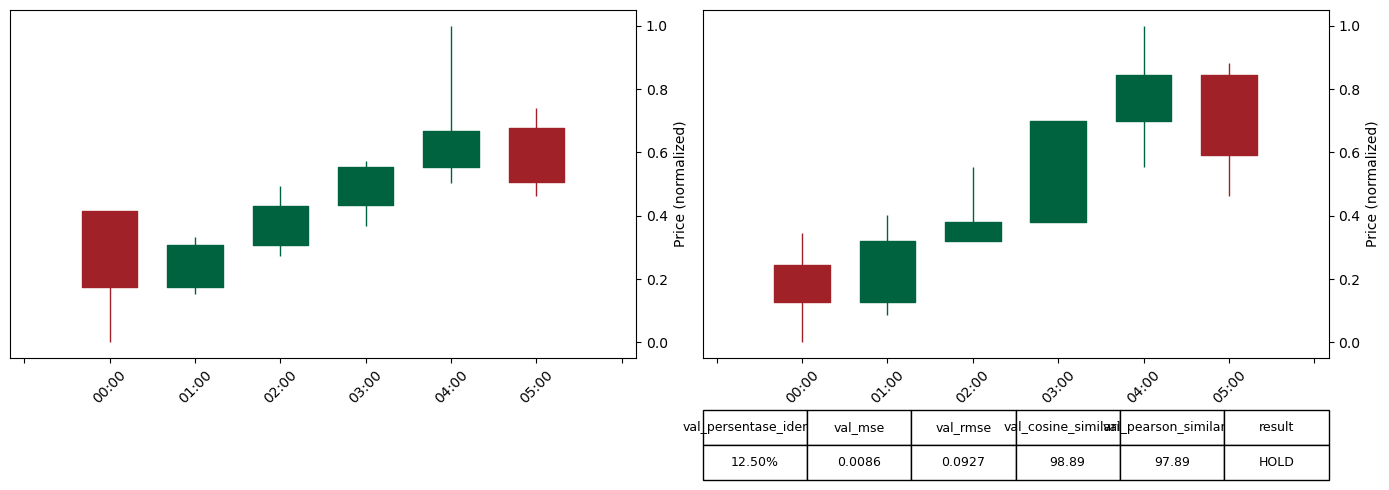

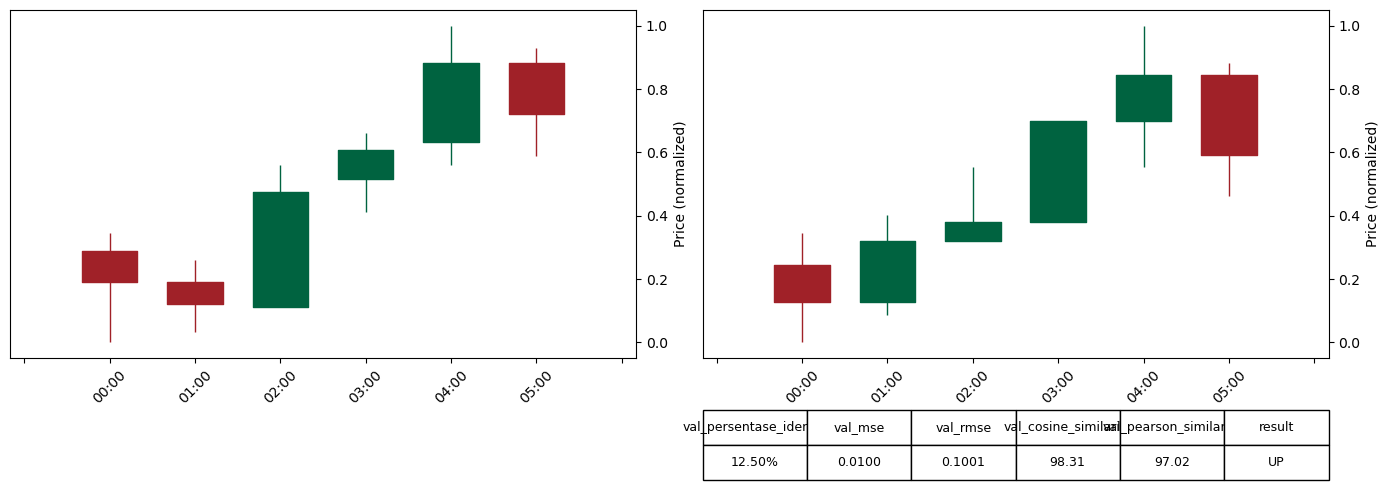

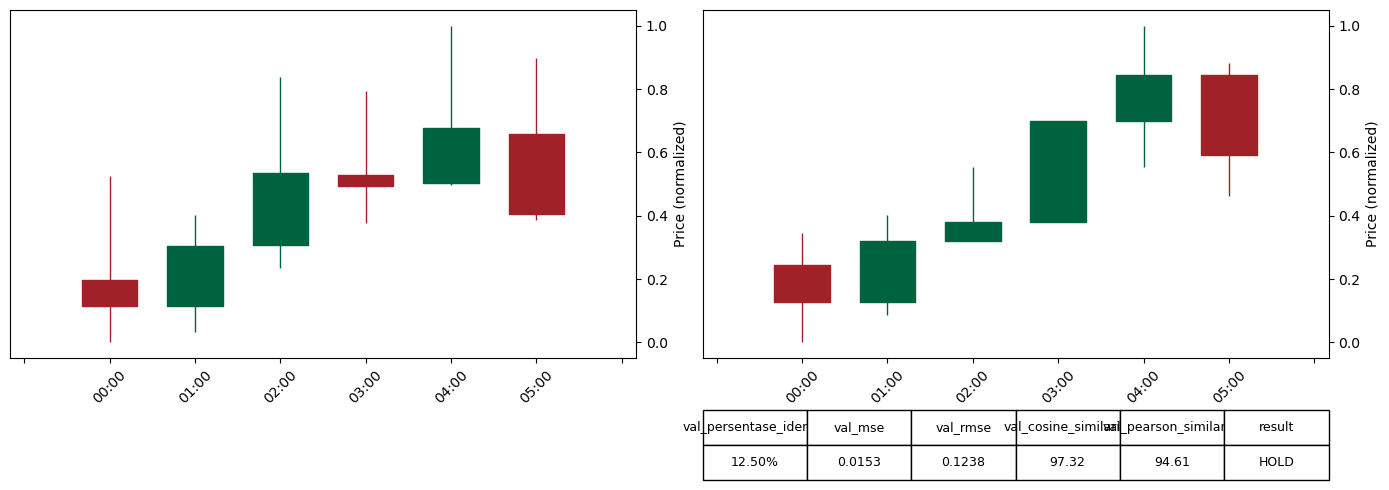

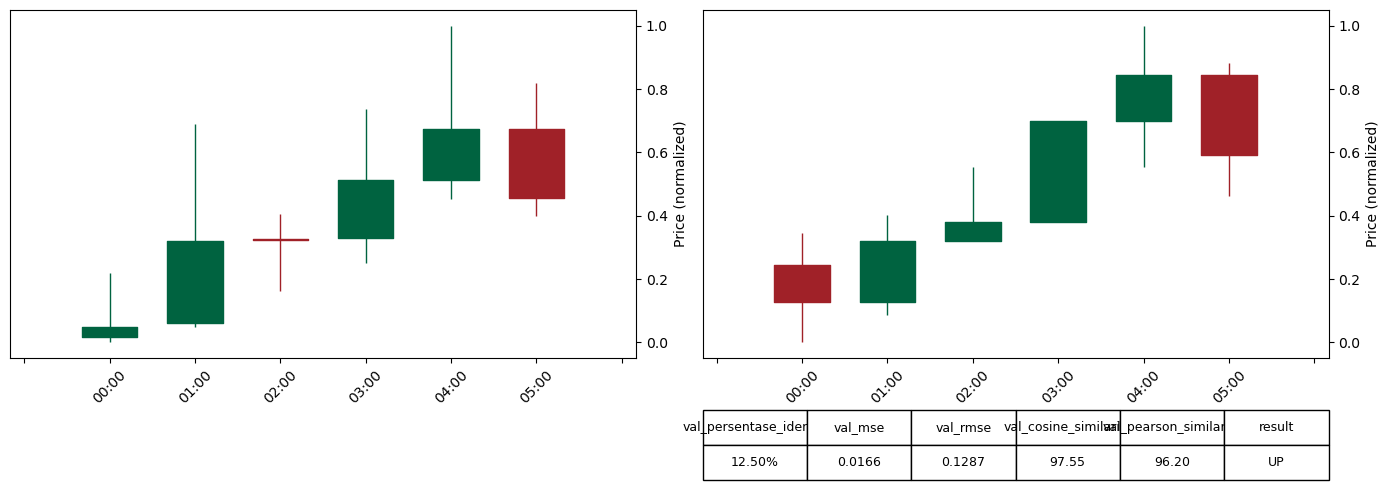

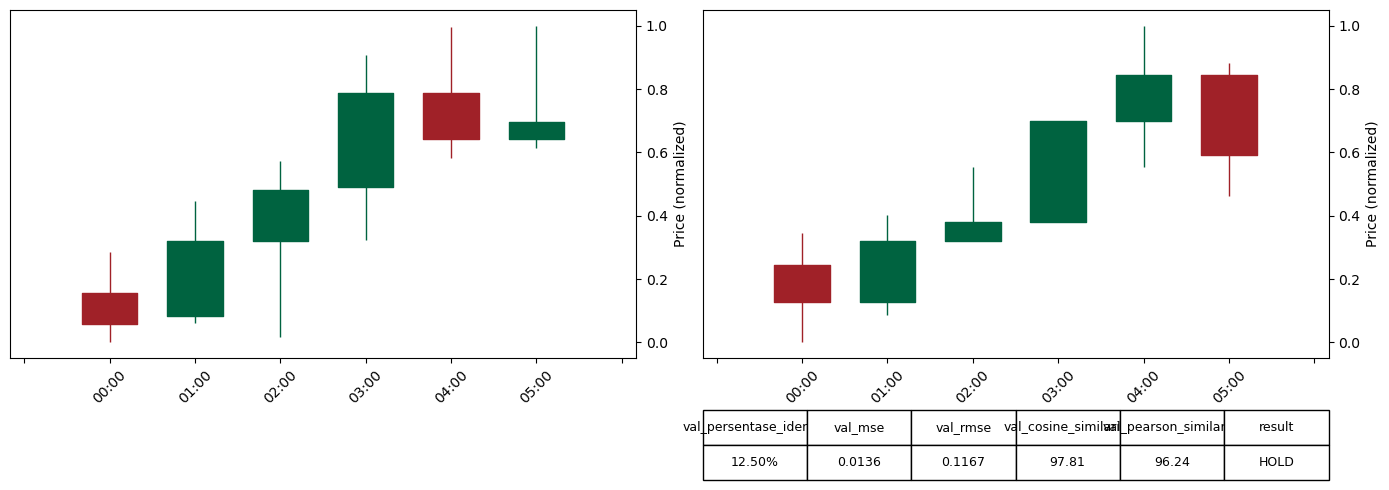

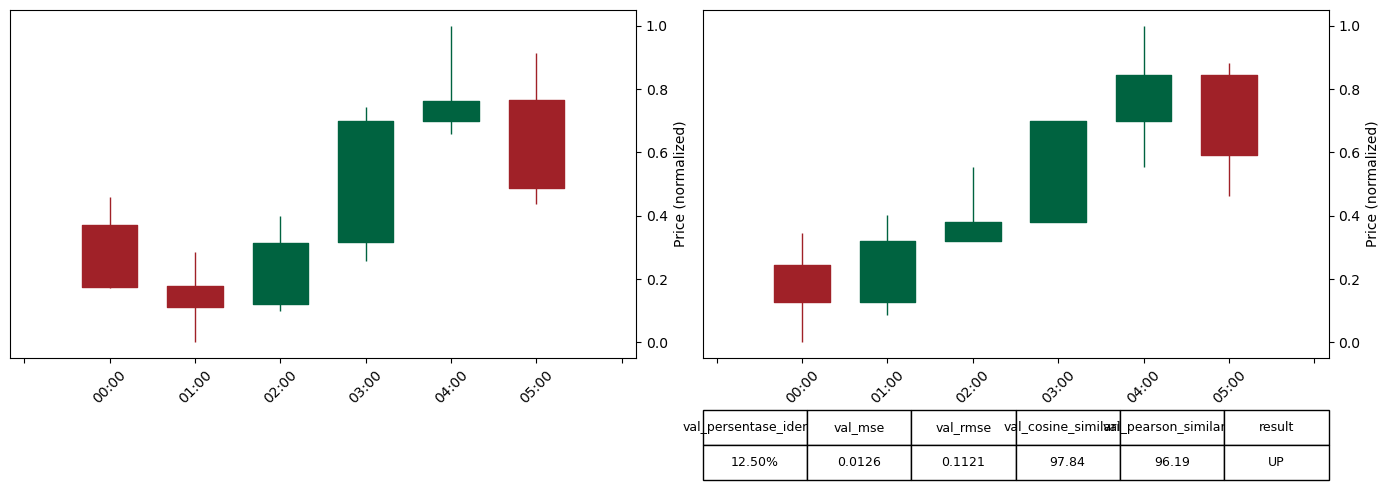

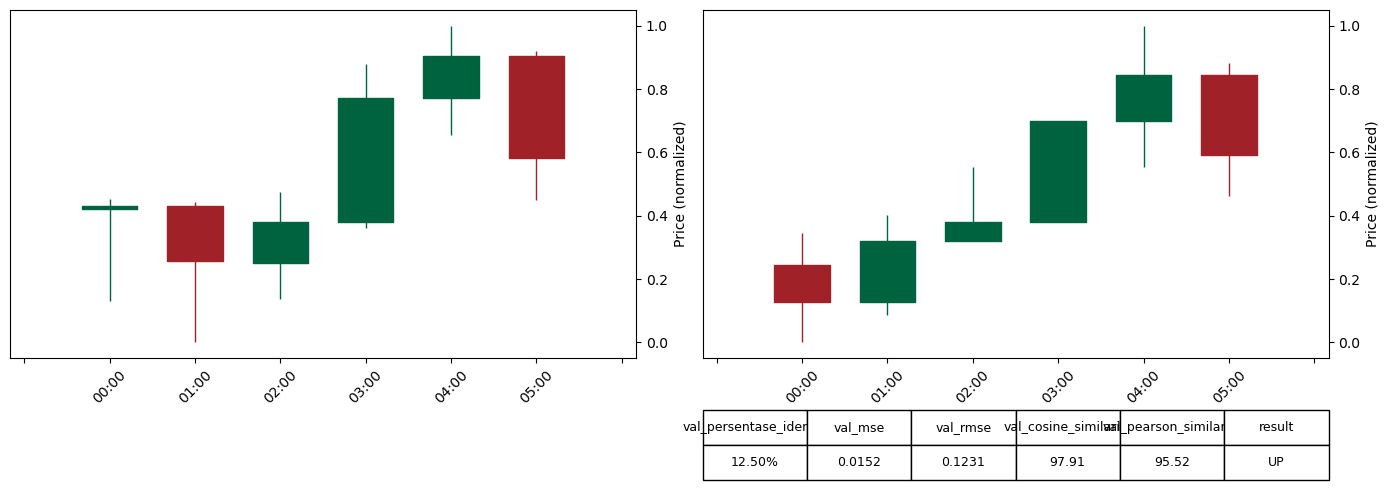

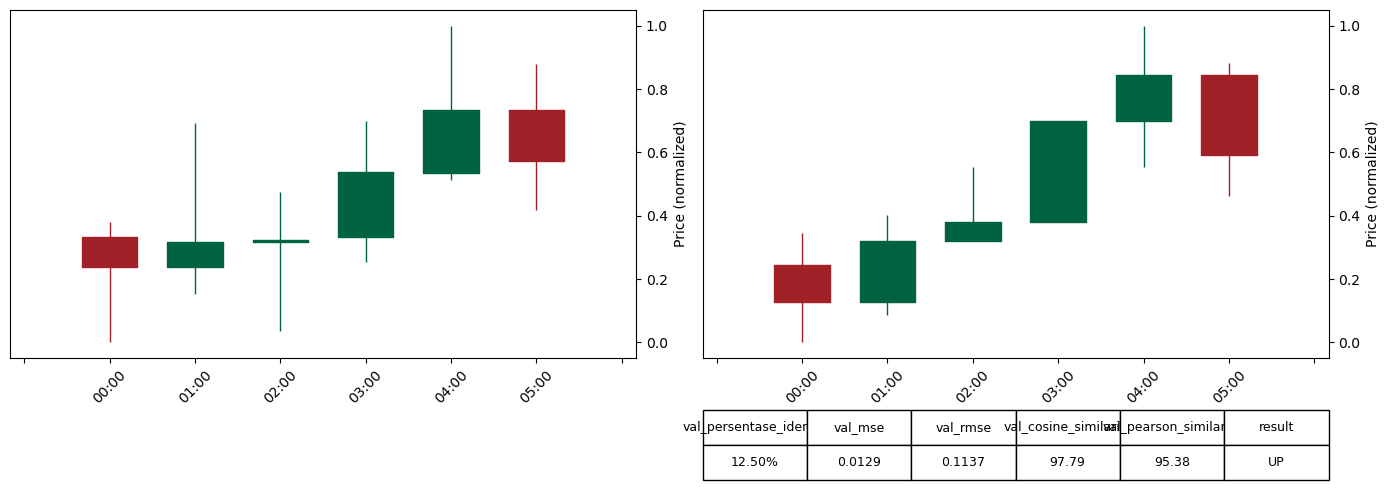

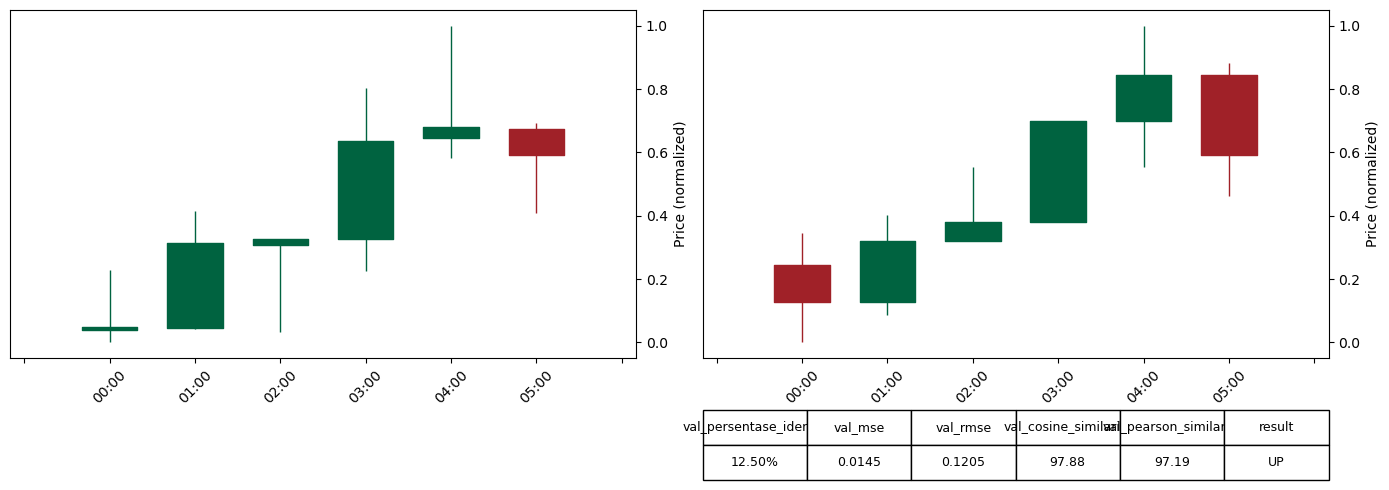

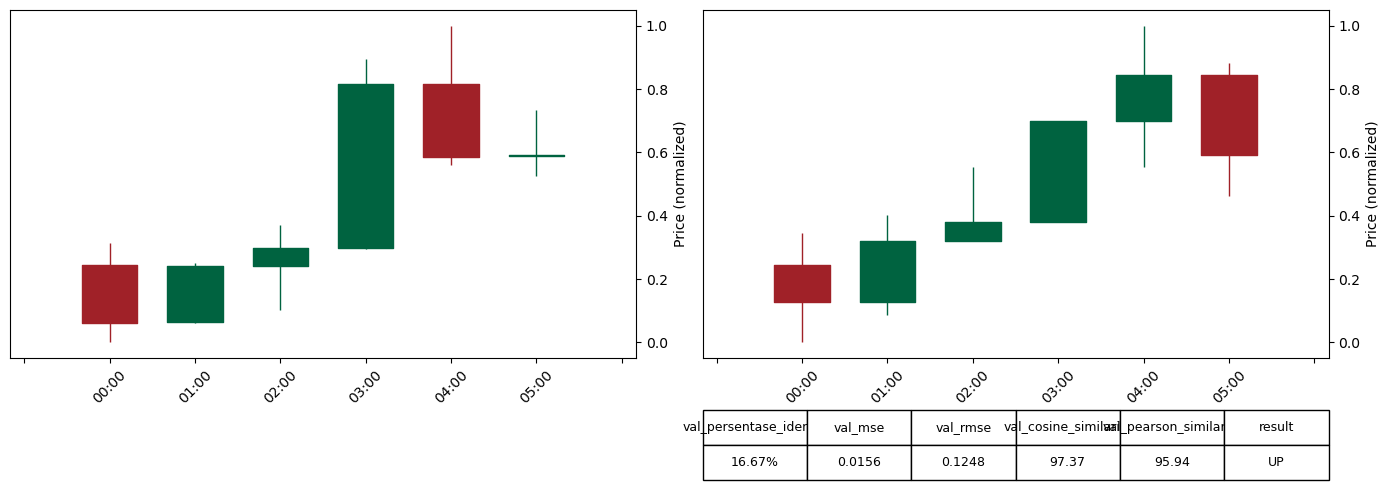

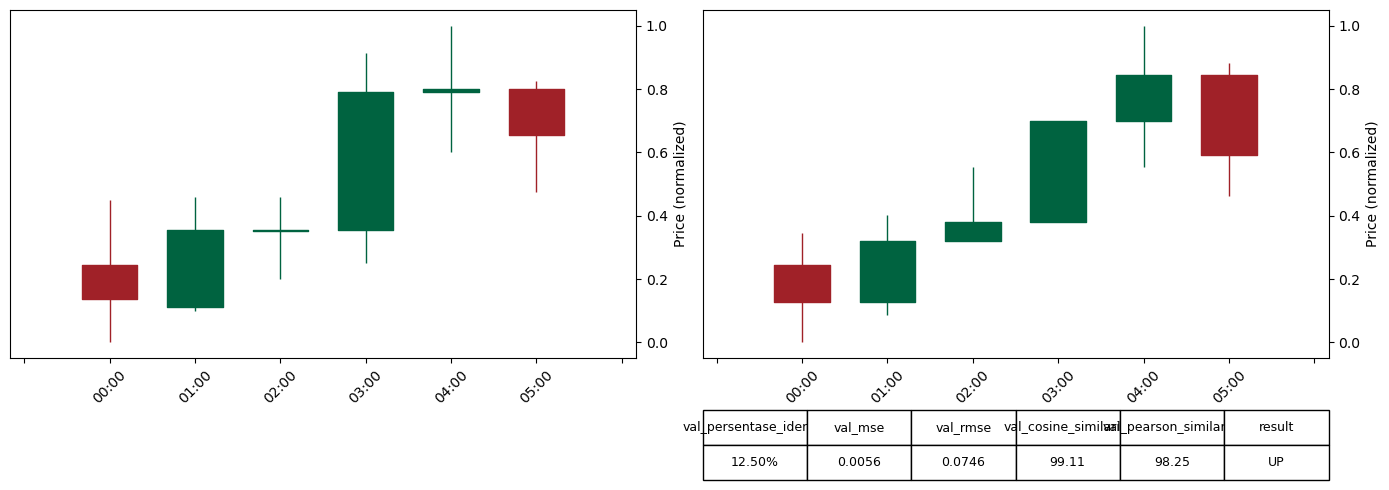

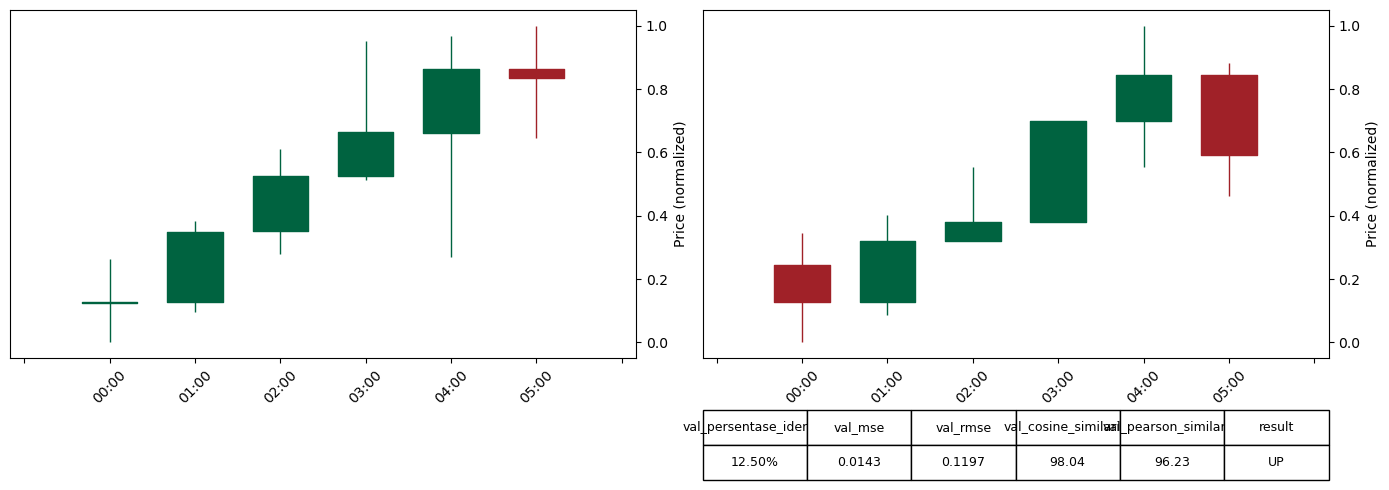

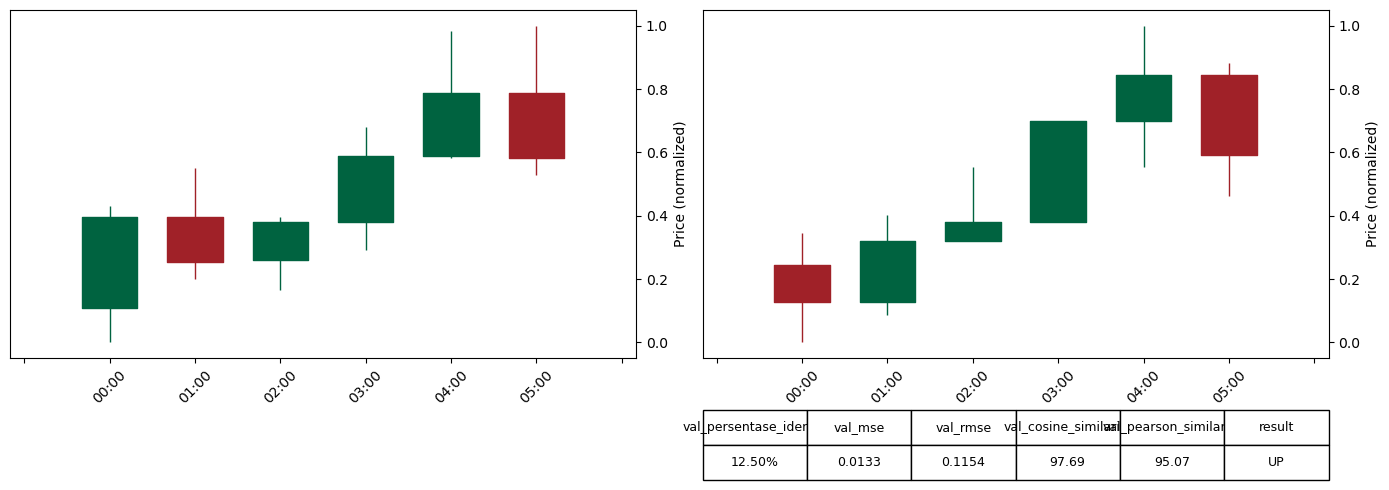

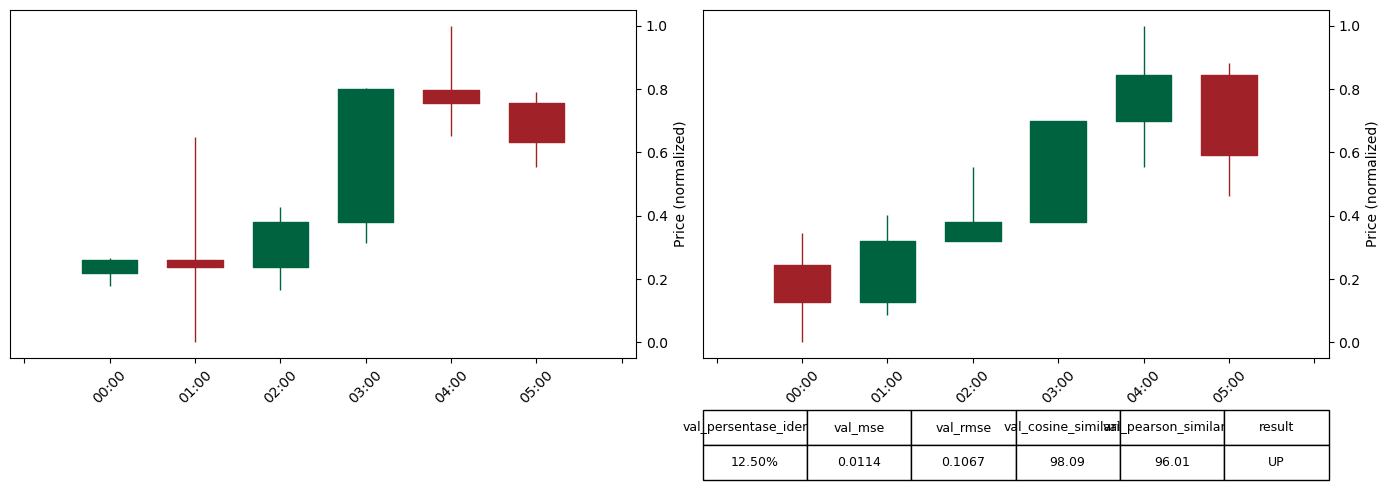

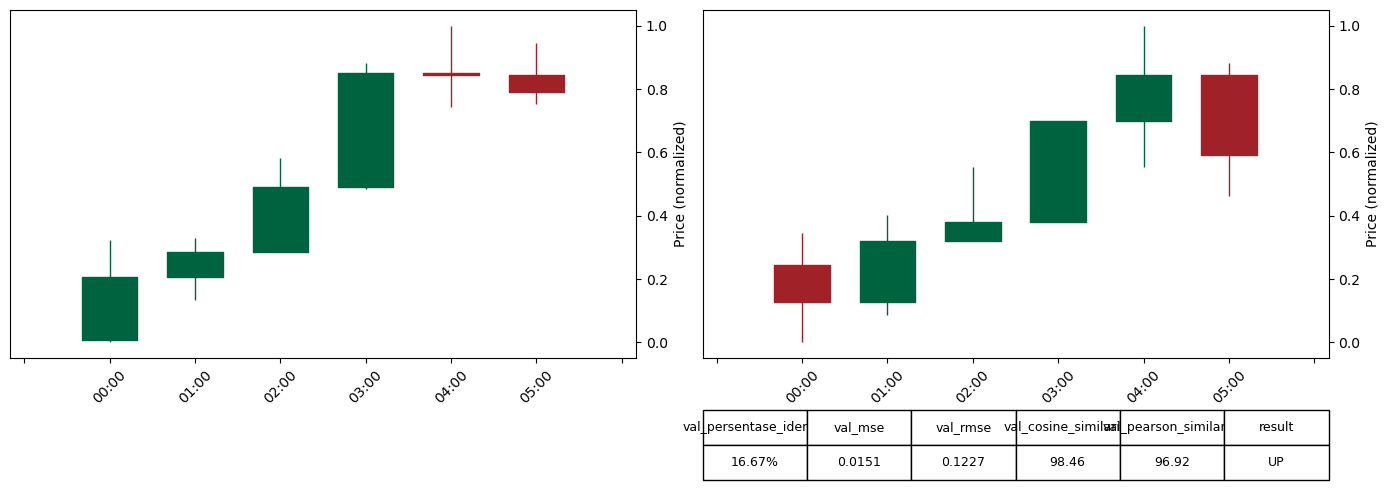

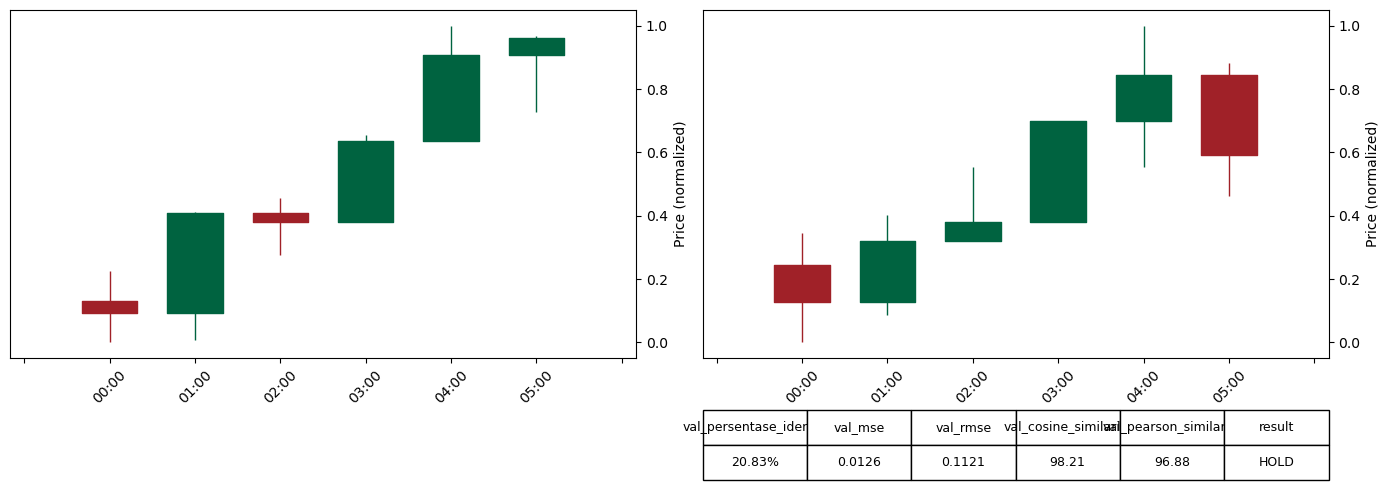

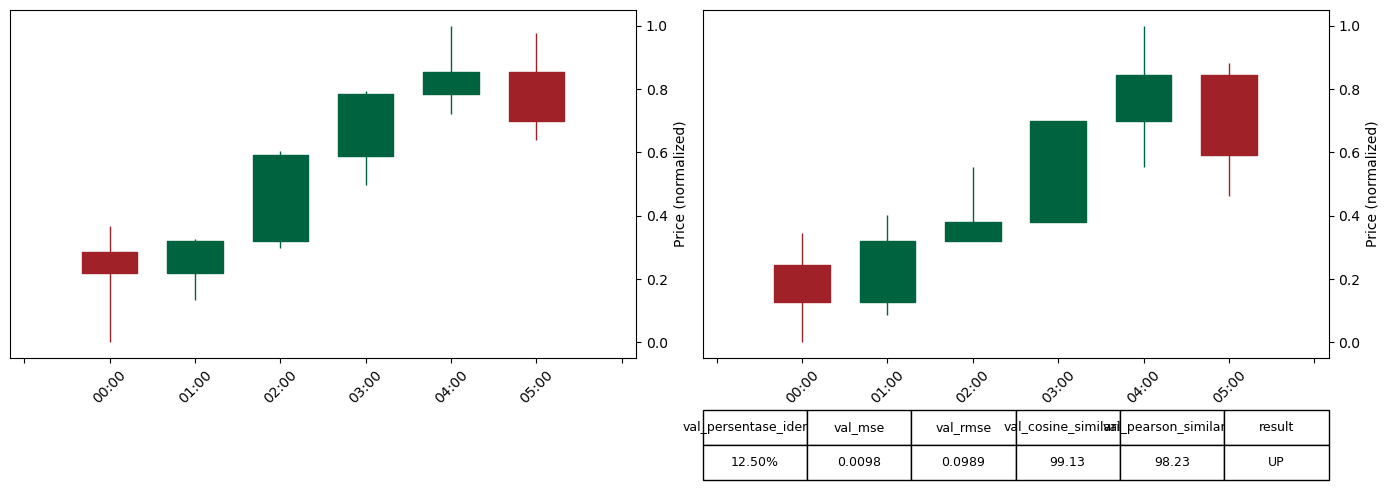

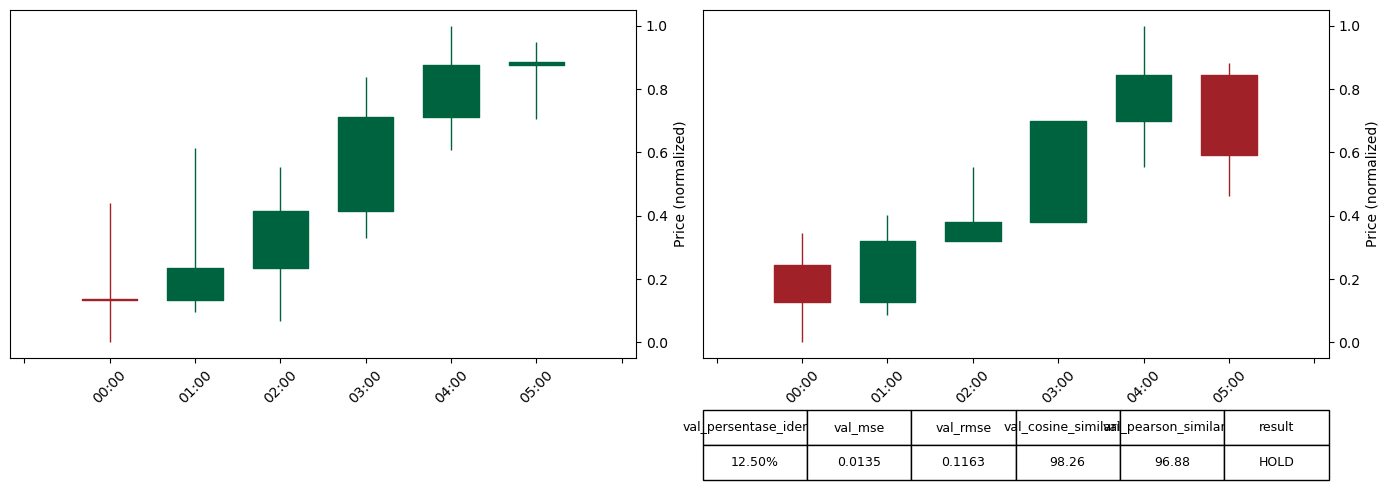

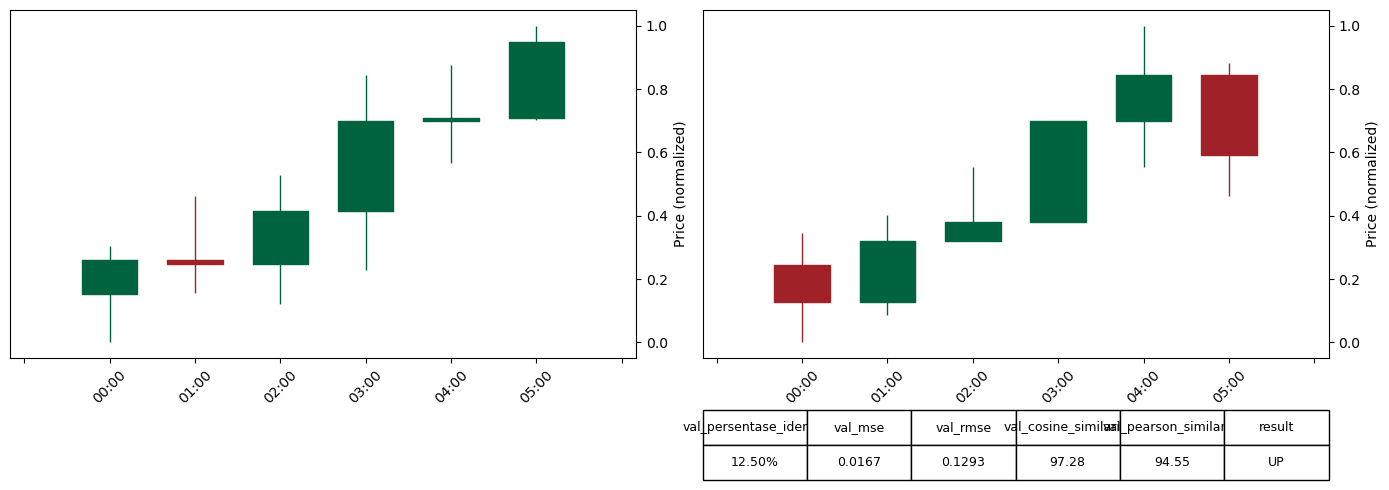

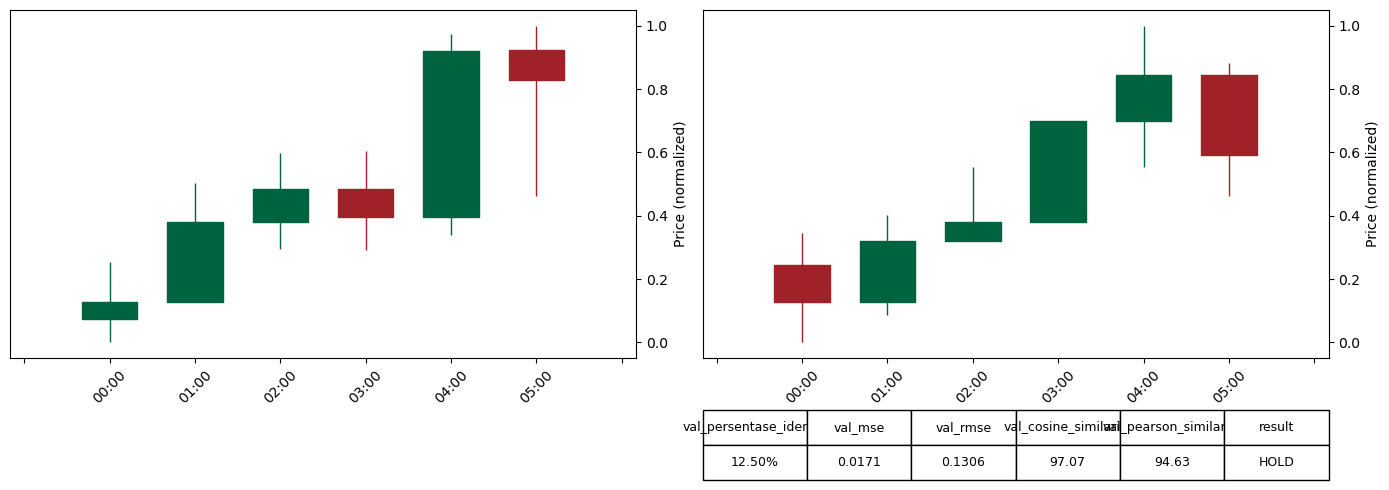

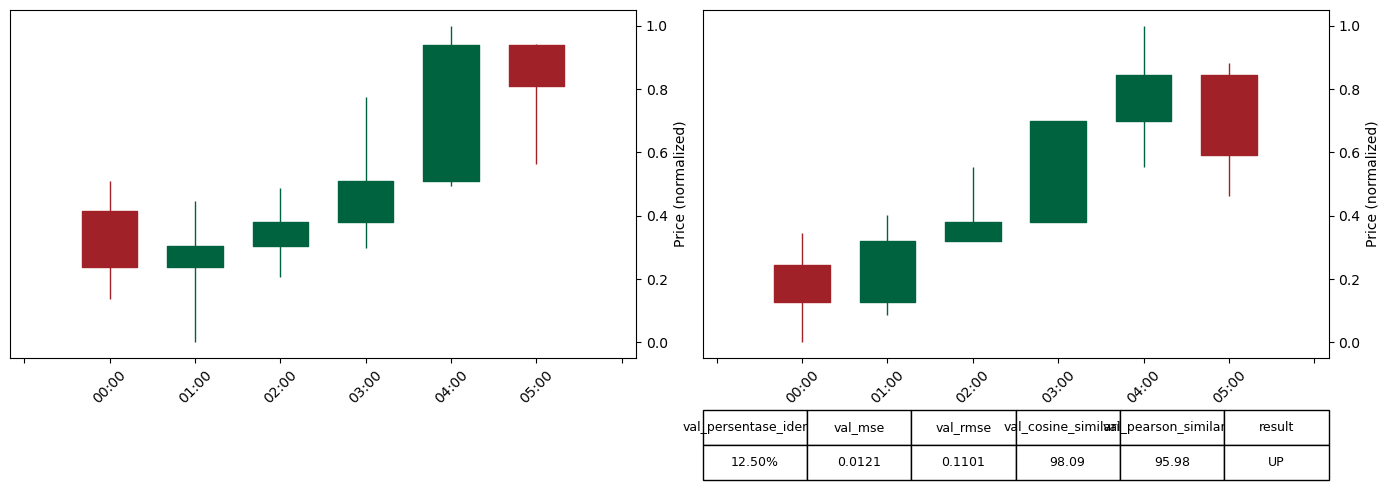

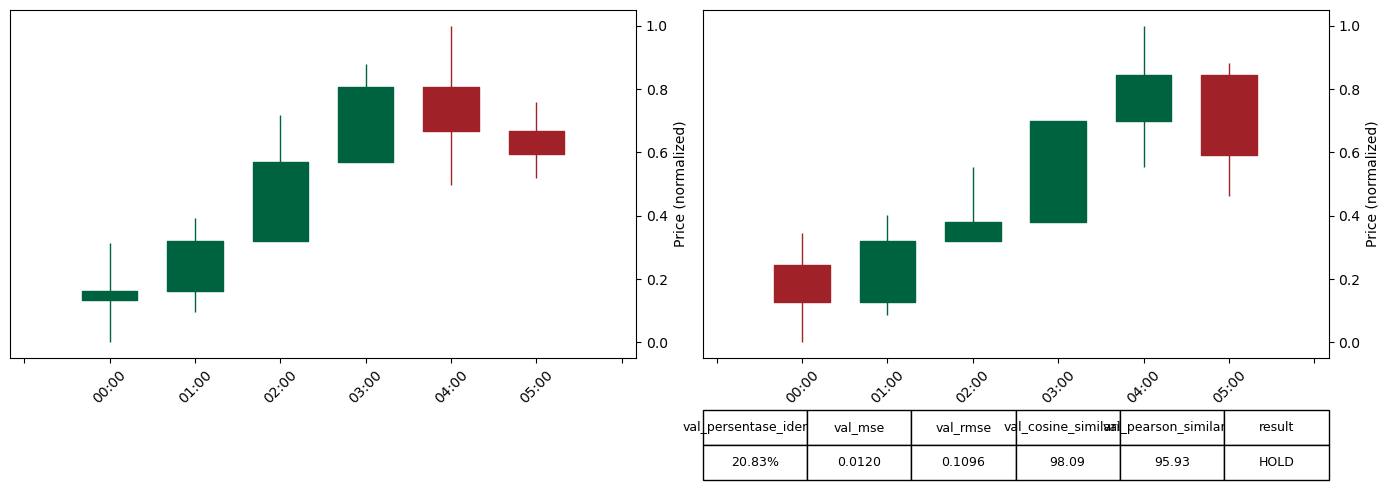

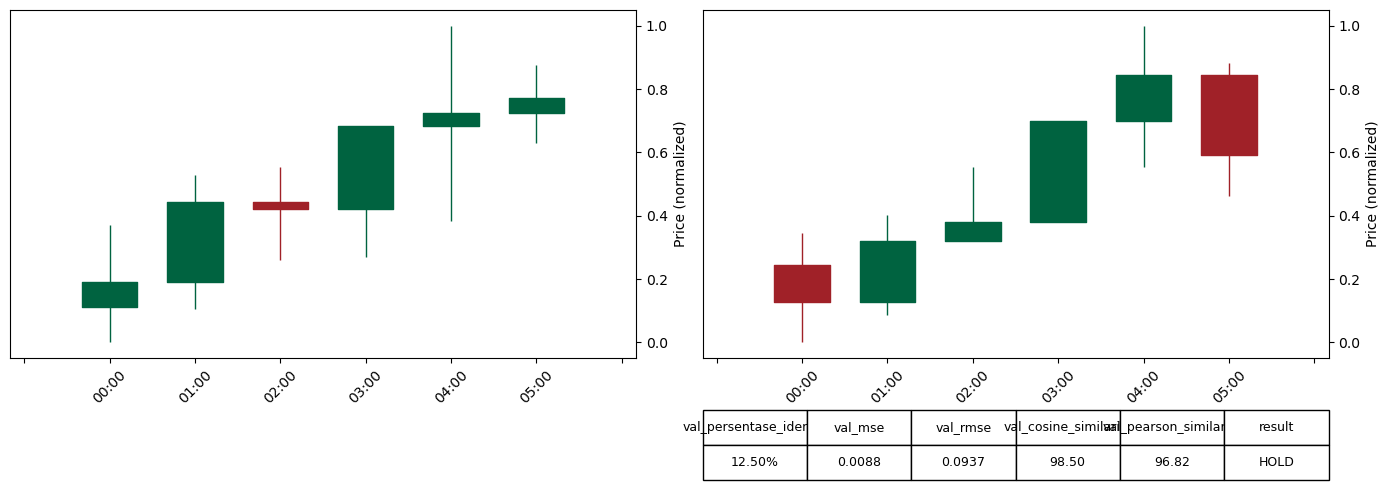

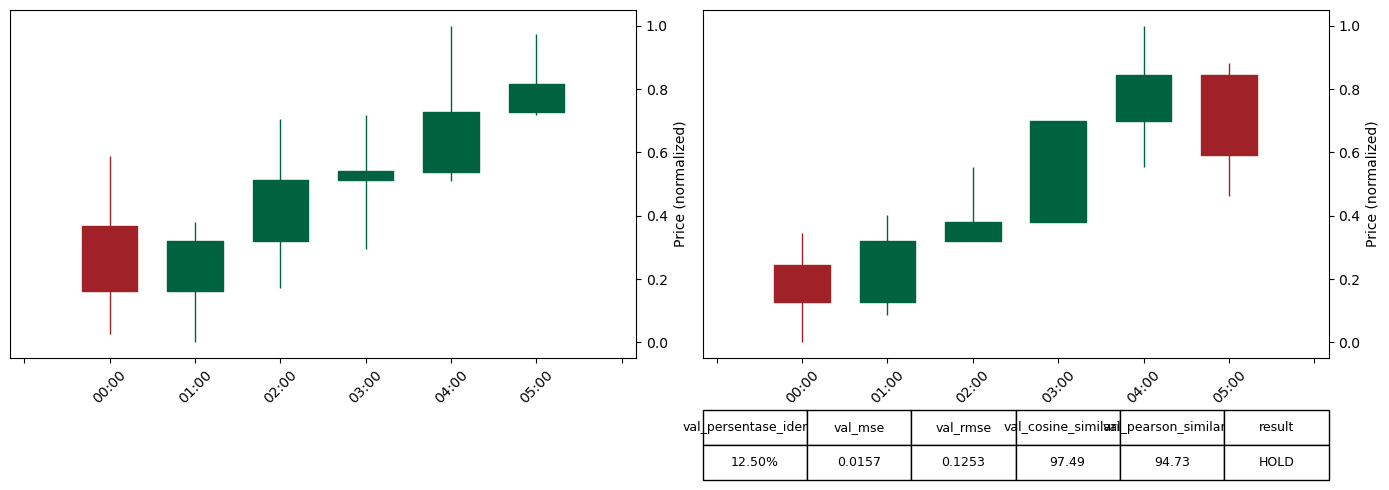

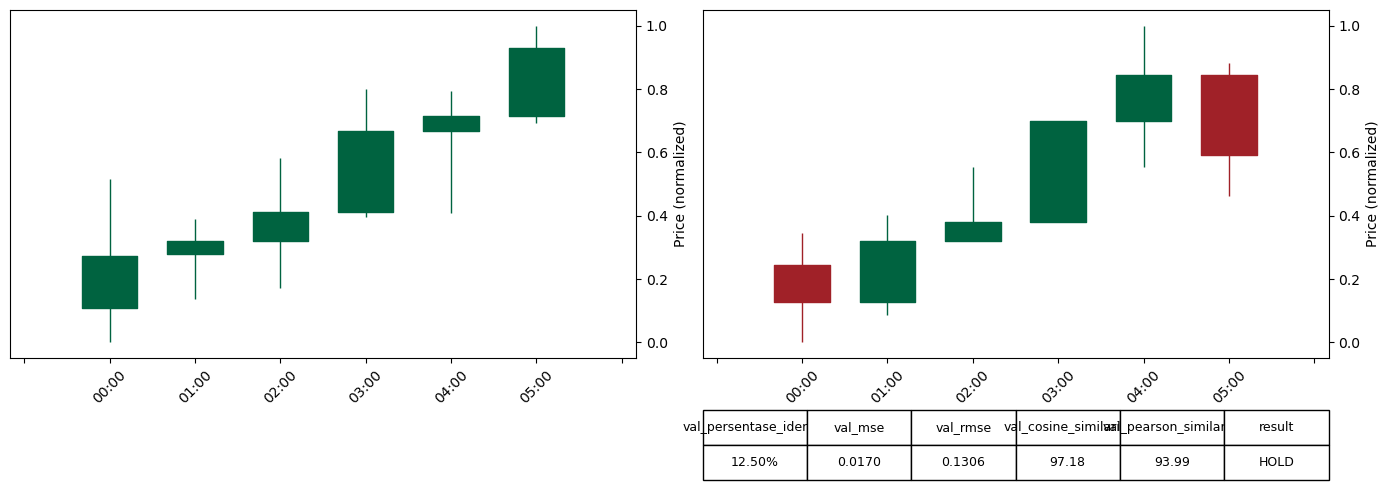

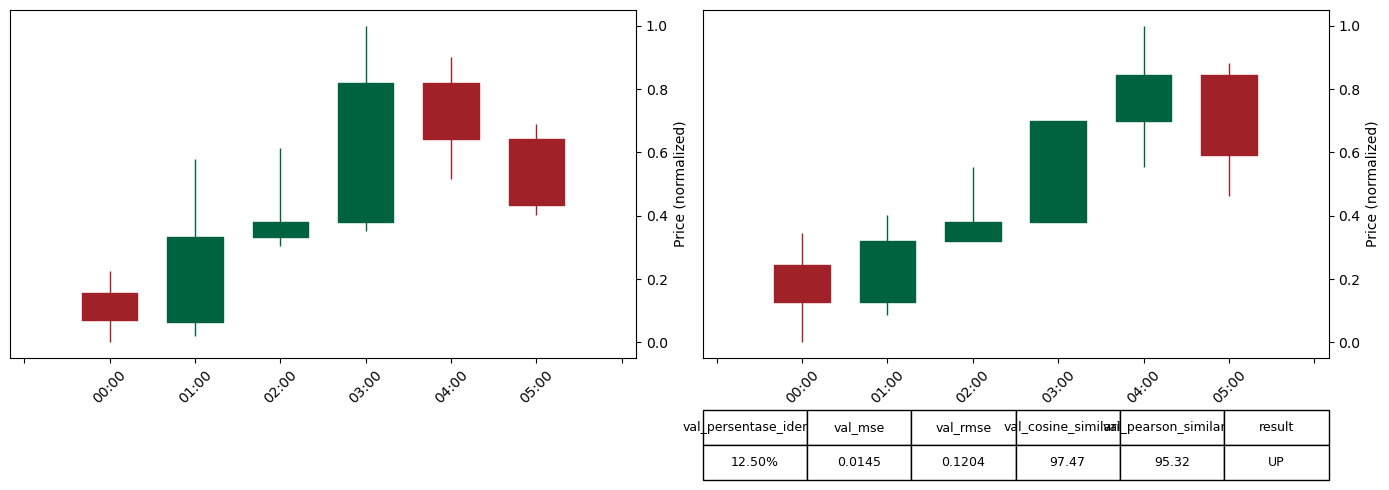

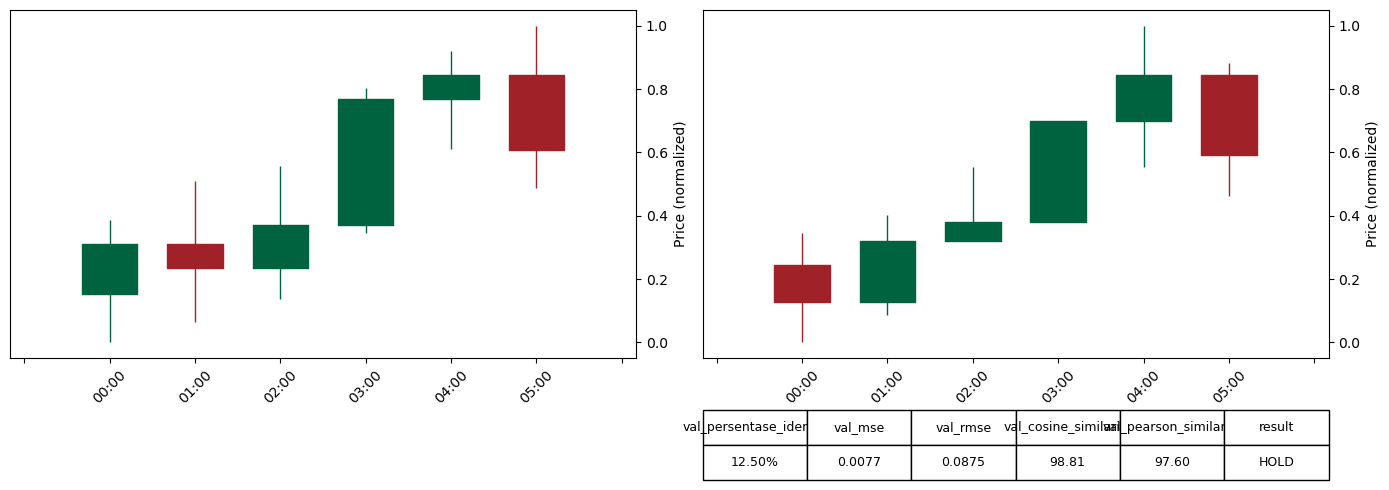

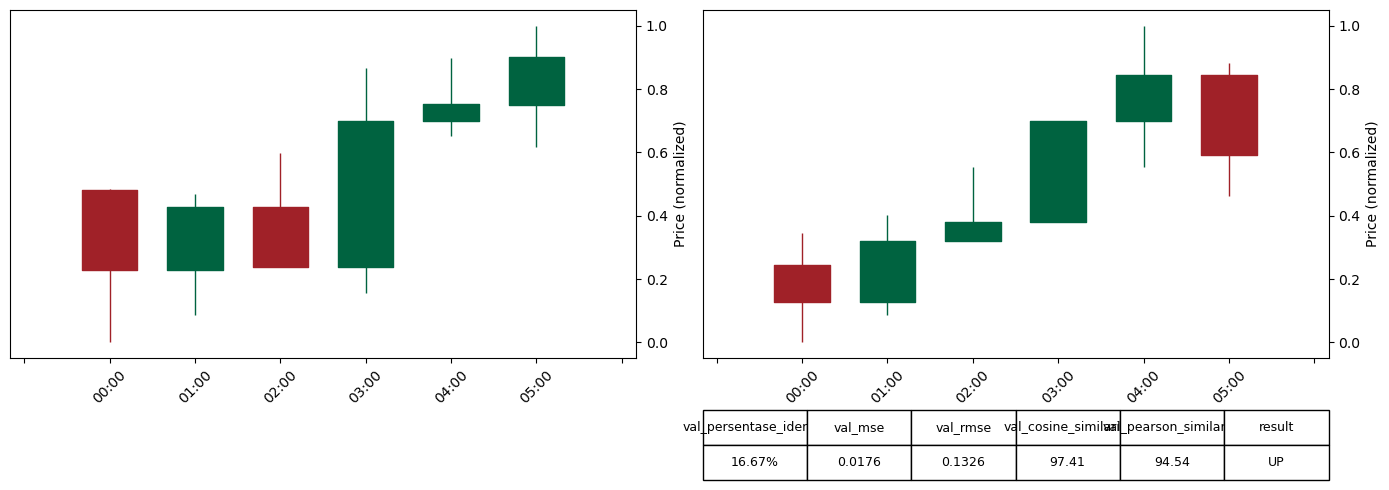

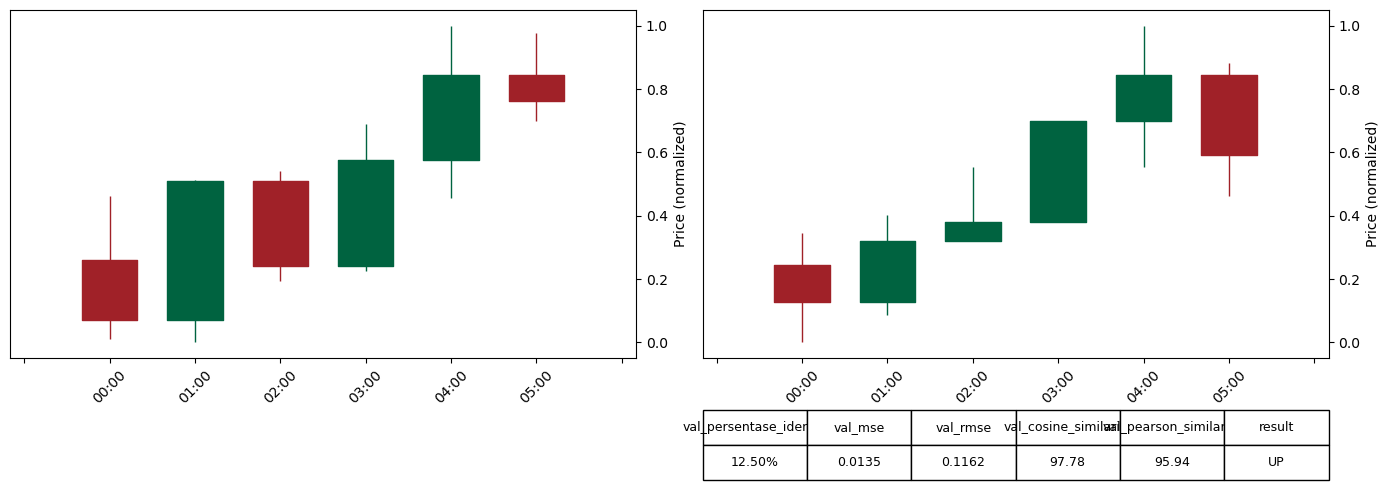

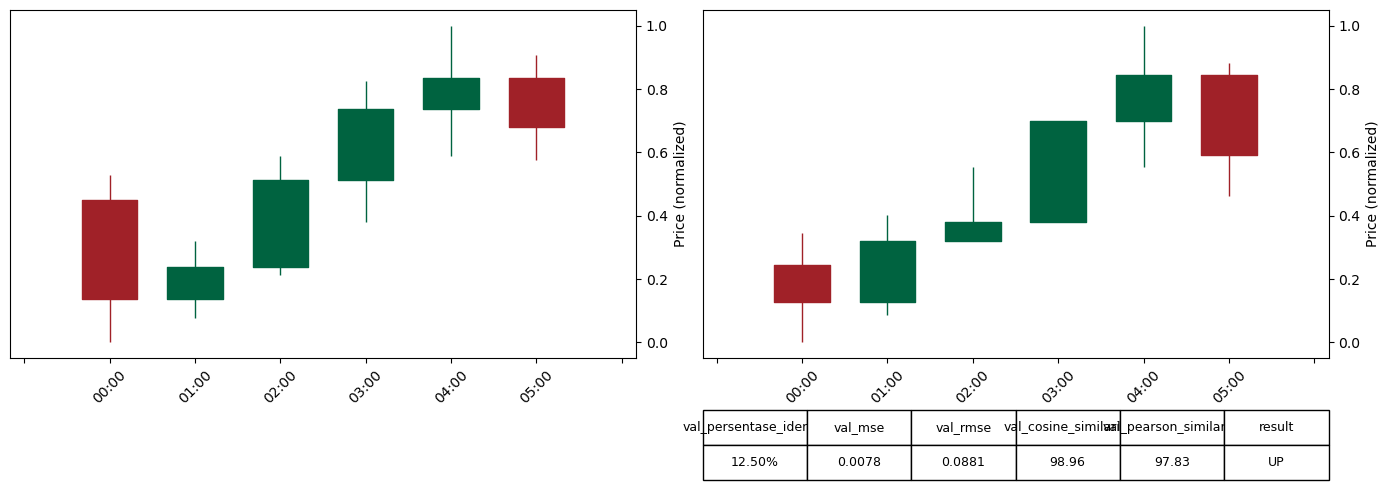

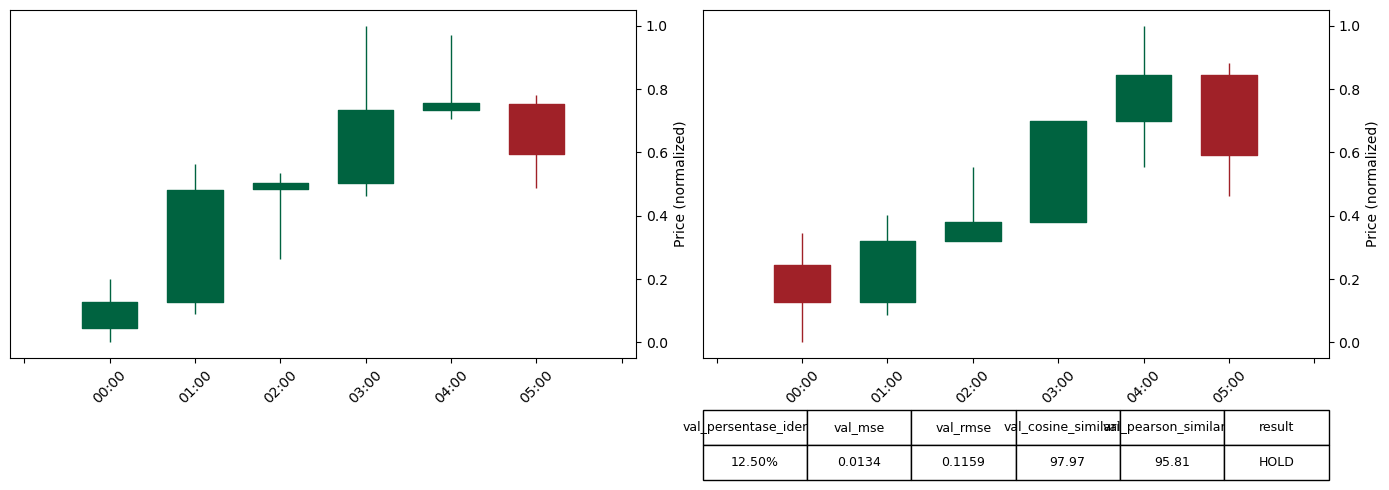

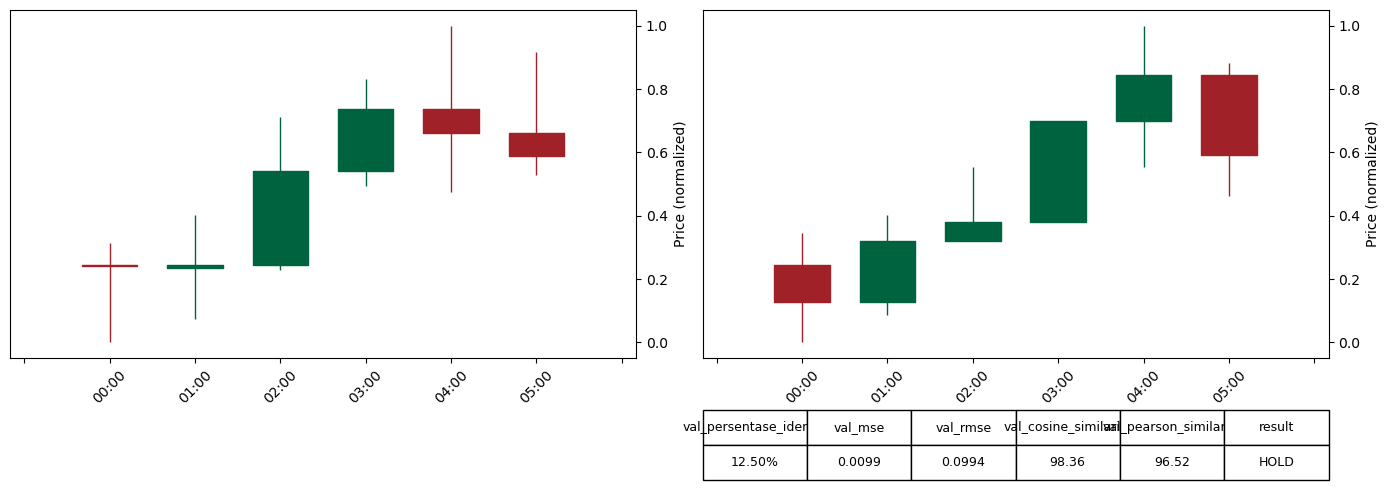

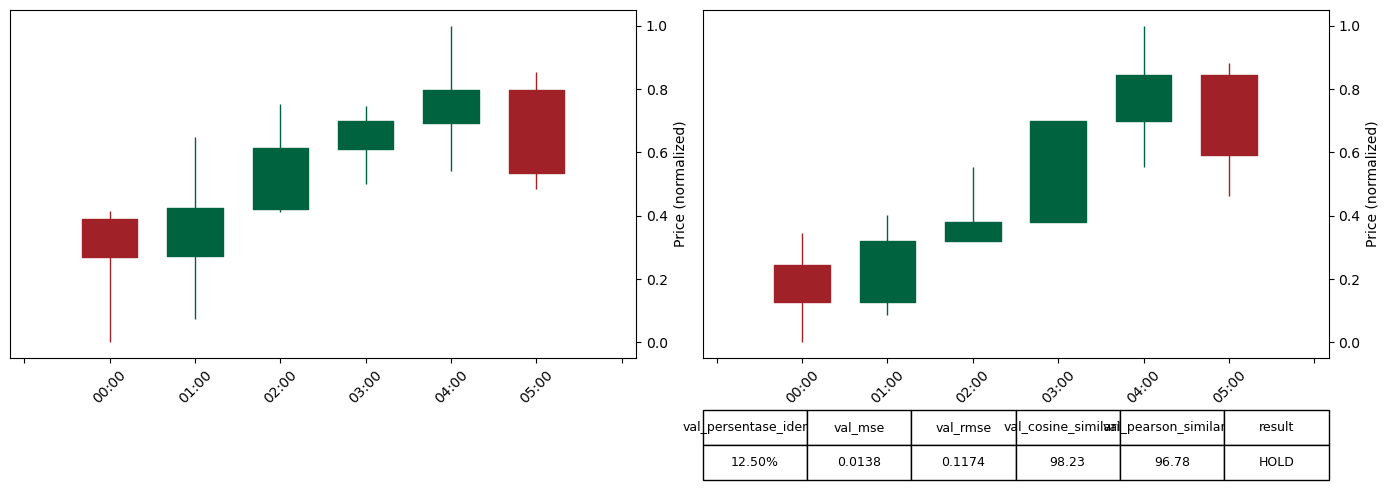

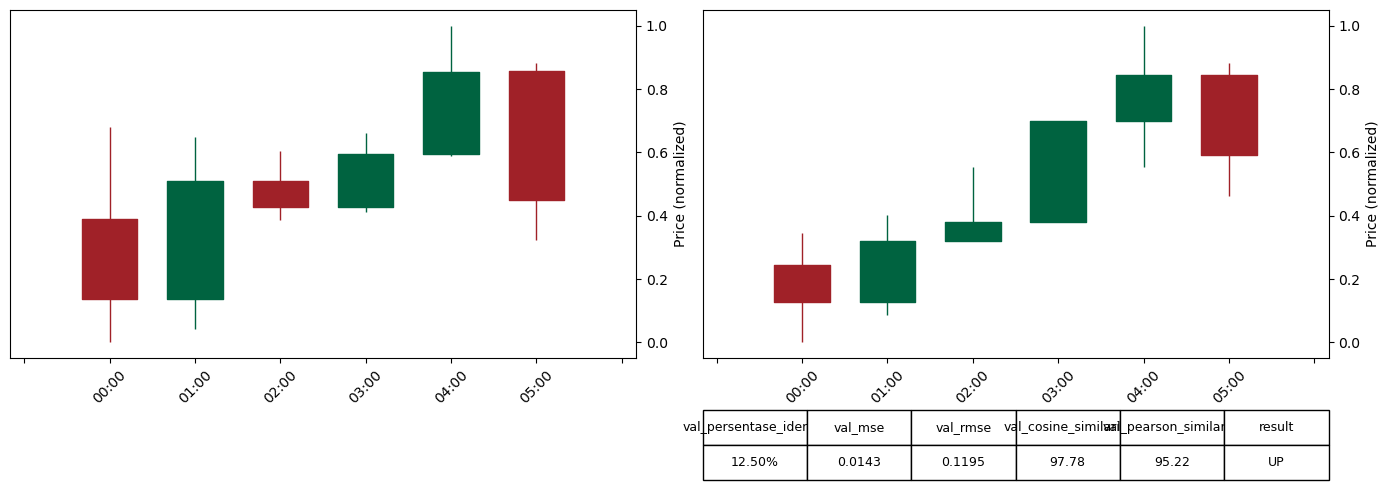

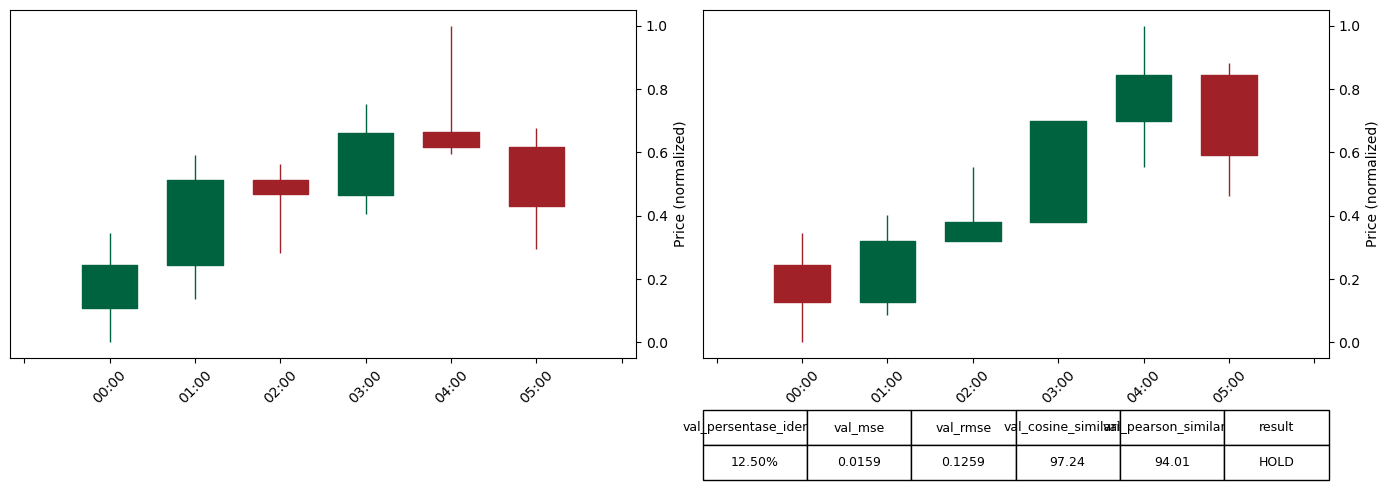

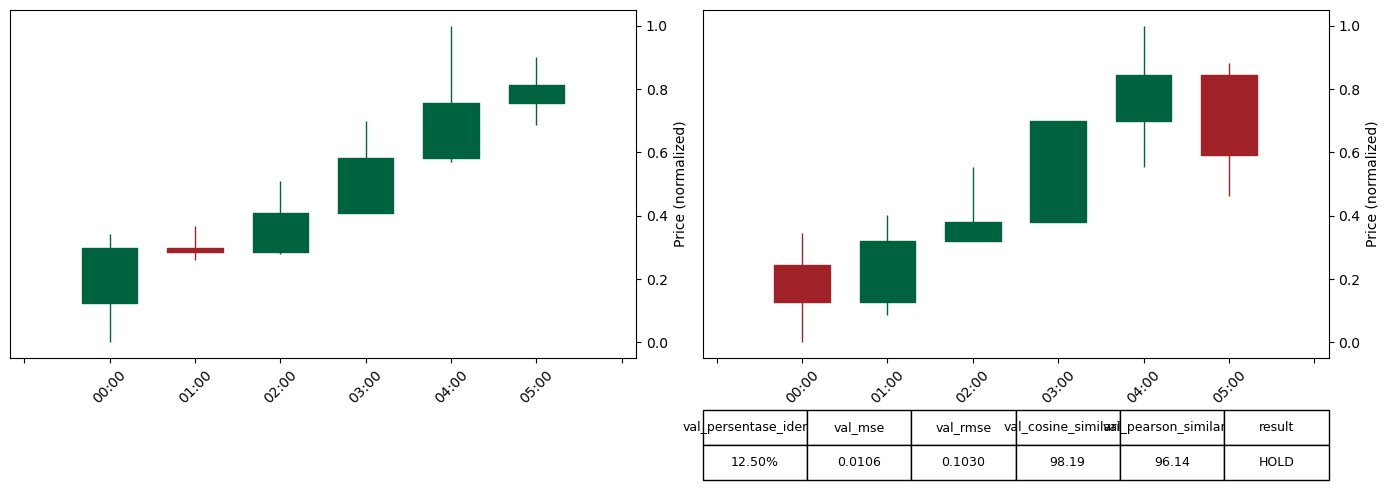

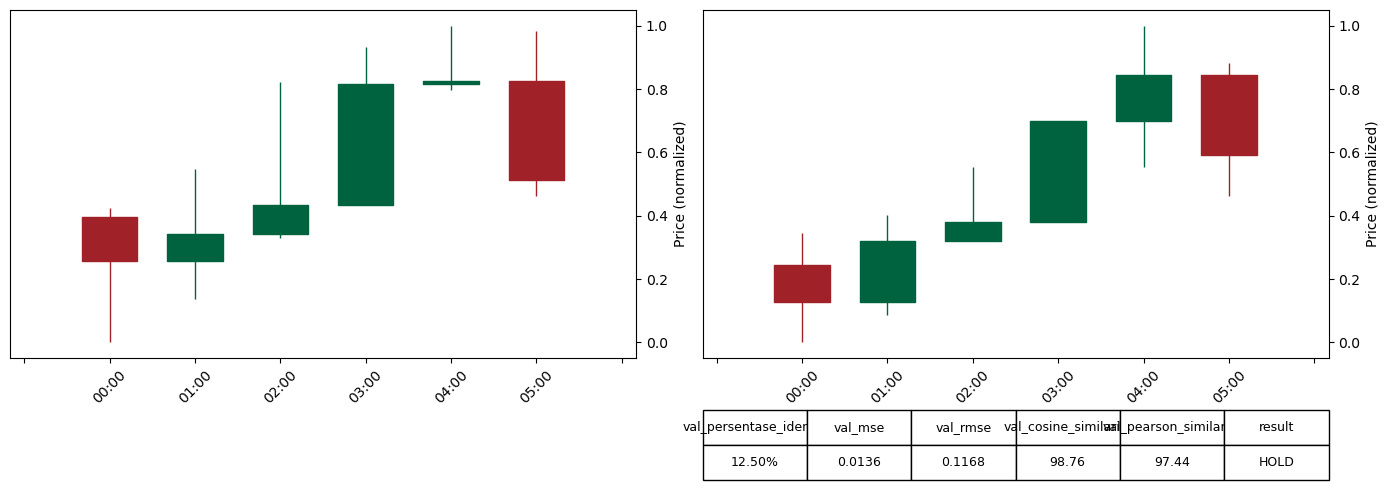

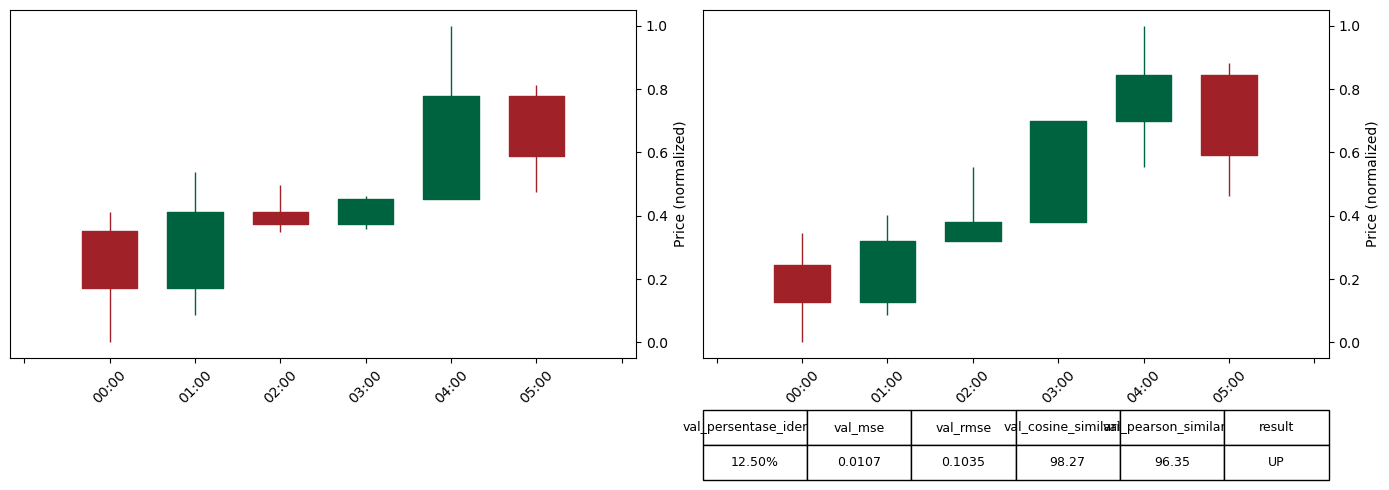

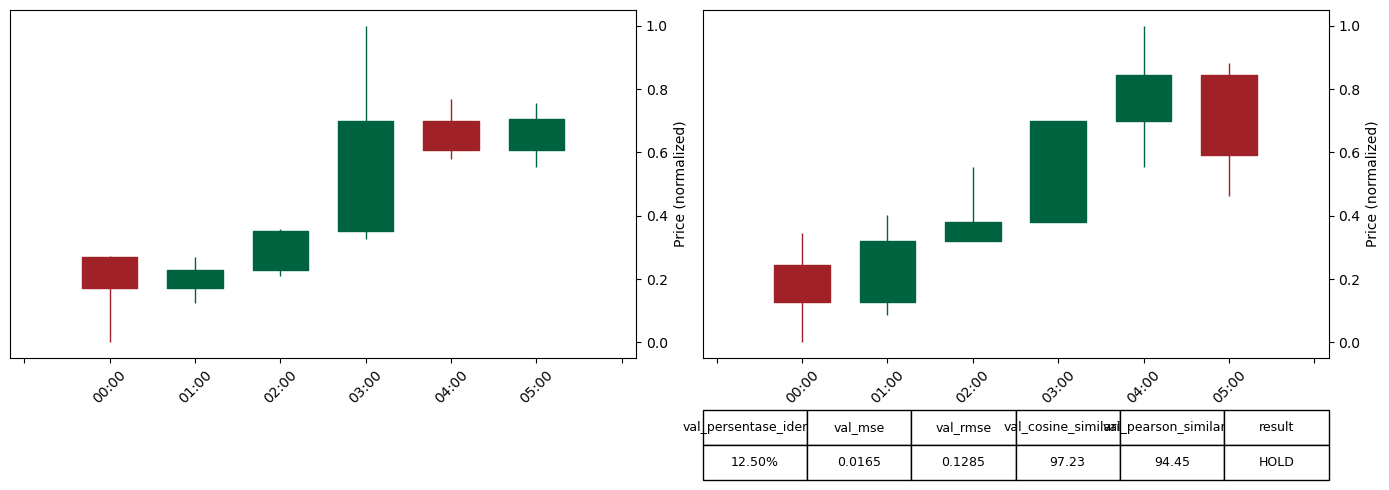

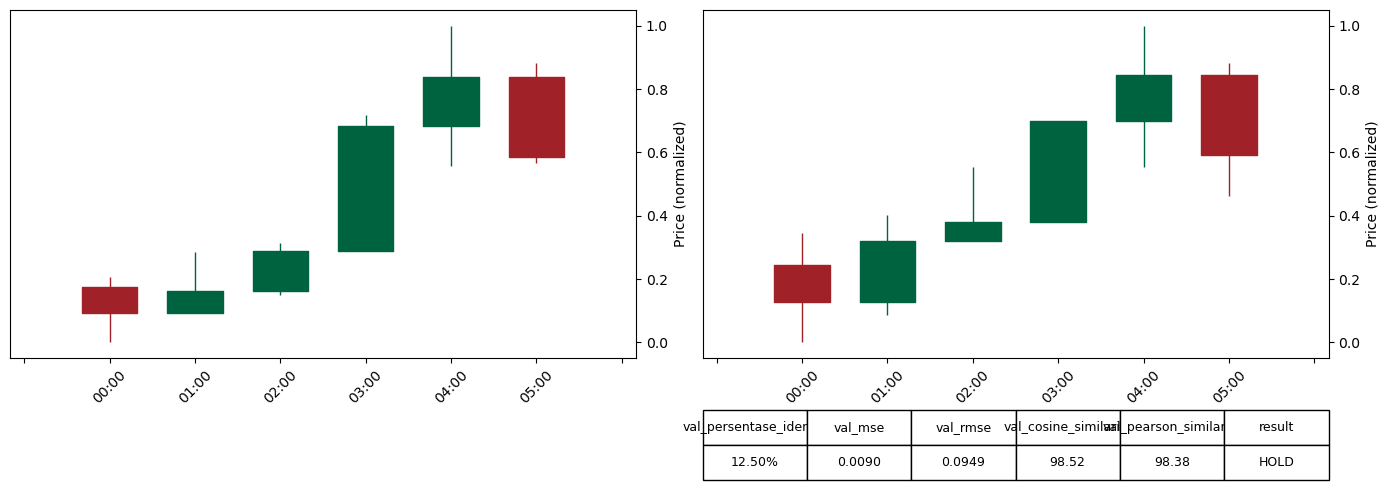

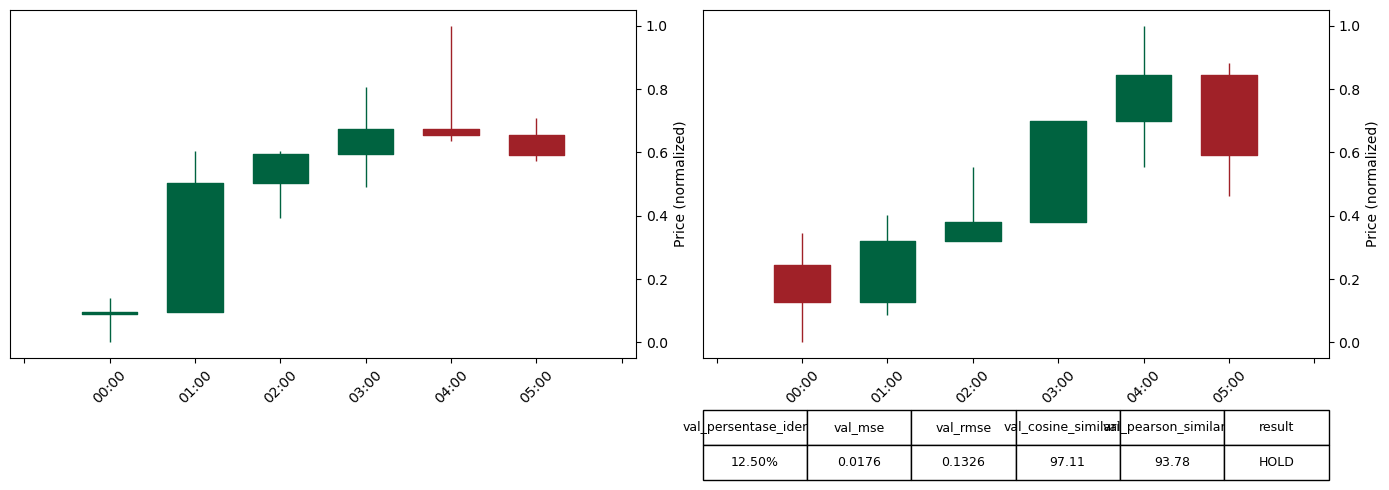

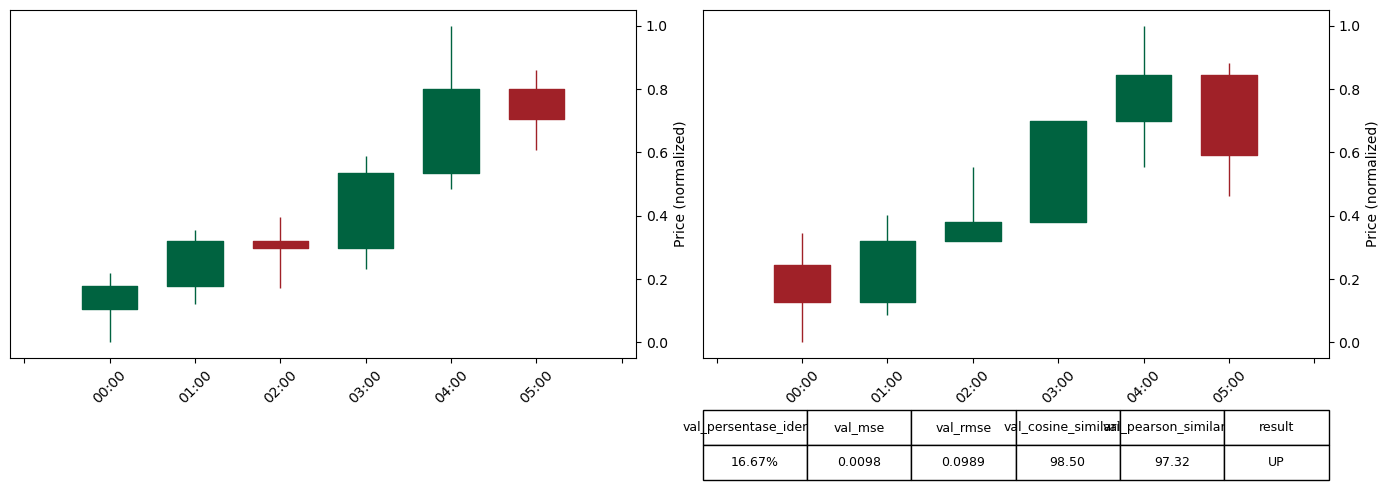

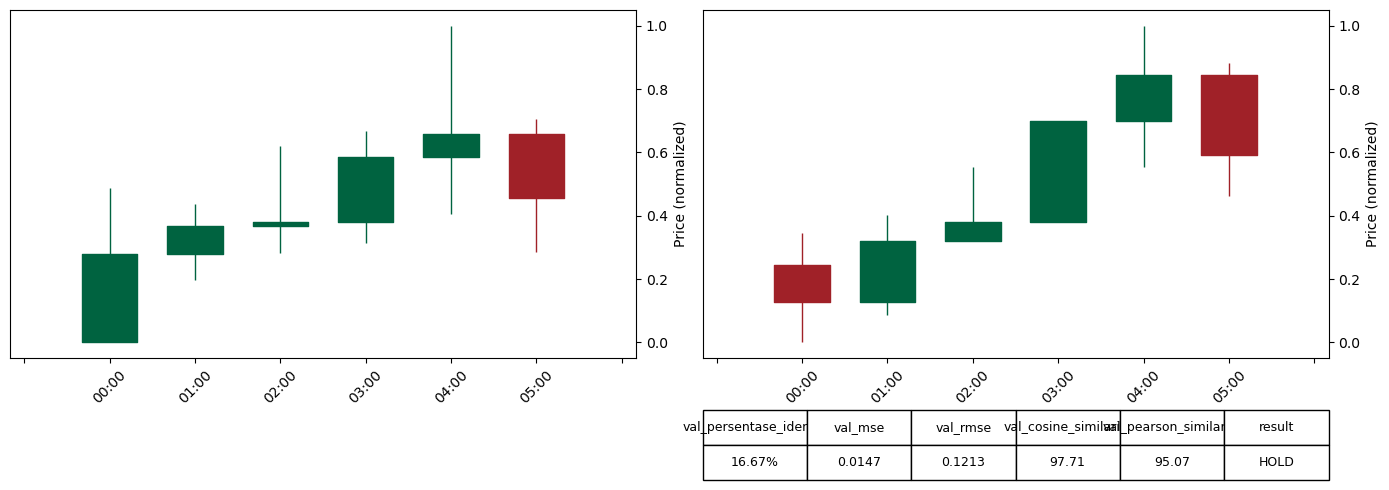

In [21]:
for i in range(len(results)):
    d = results[i]
    show_candlestick_comparison(d, target_norm[numeric_cols].values.tolist())

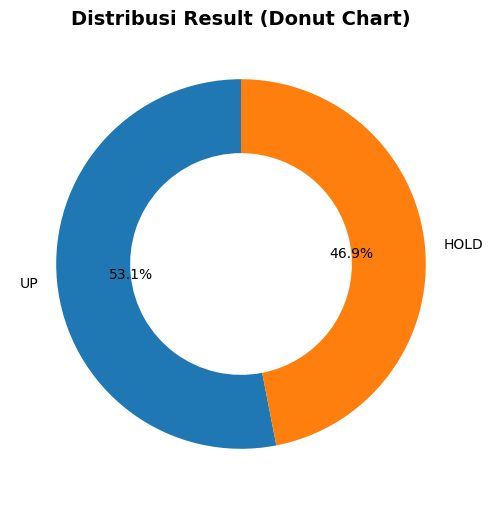

In [22]:
import matplotlib.pyplot as plt

def plot_donut_result(df):
    result_counts = df['result'].value_counts()

    fig, ax = plt.subplots(figsize=(6, 6))
    wedges, texts, autotexts = ax.pie(
        result_counts,
        labels=result_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.4}  # ini bikin jadi donat
    )

    # Judul
    ax.set_title("Distribusi Result (Donut Chart)", fontsize=14, fontweight='bold')
    plt.show()

# Contoh pemanggilan
plot_donut_result(df)
